# Анализ ассортимента методом ABC/XYZ

**Автор:** Костылевская Наталия

**Дата:** 06.10.2026 г.

### Для проекта используется открытый набор данных Online Retail II.
Для основного анализа был выбран временной диапазон длиной в последние 12 полных месяцев как наиболее "свежий" и потому актуальный (с 10 декабря 2010 по 30 ноября 2011 г.).

## Описание данных:

Датасет `Online Retail II` представляет собой транзакционные данные британского интернет-магазина подарков: одна строка соответствует позиции в счете/заказе.

Таблица содержит следующие поля:
- `InvoiceNo` - номер счета / заказа;
- `StockCode` - код товарной позиции (SKU);
- `Description` - описание / название товара;
- `Quantity` - количество единиц товара в операции;
- `InvoiceDate` - дата и время операции;
- `UnitPrice` - цена одной единицы товара;
- `CustomerID` - идентификатор покупателя;
- `Country` - страна клиента.

## Цели и задачи:
**Цели:**
- провести комбинированный ABC/XYZ анализ ассортимента и сегментировать товары по их экономической значимости и вариативности физического спроса;
- составить аргументированный список товаров-кандидатов на удаление из ассортимента с оценкой гипотетической потери выручки. Ожидается сокращение ассортимента приблизительно на 20%.

**Задачи:**
- загрузить данные и ознакомиться с ними;
- подготовить данные: определить наличие пропусков, дубликатов, аномальных значений. Проанализировать возможные причины их возникновения и определить стратегию их обработки;
- выбрать временной период, рассматриваемый в  основном анализе;
- изучить динамику выручки и количества заказов за выбранный период;
- провести ABC-анализ, присвоить каждому товару группу, визуализировать группы при помощи кривой Парето;
- провести XYZ-анализ, присвоить каждому товару группу, обозначить новые и молодые товары;
- определить сезонные товары и обозначить их;
- присвоить каждому товару комбинацию ABC и XYZ-групп;
- составить объединенную матрицу ABC/XYZ, подсчитать метрики для каждой комбинации;
- сформулировать рекомендации по стратегии управления товарами в каждой комбинированной группе, учитывая ранее отмеченные товары: новые, молодые и сезонные;
- определить стратегию составления списка товаров для сокращения из товаров группы CZ;
- реализовать ранжирование слабых товаров на основании нескольких метрик;
- провести анализ чувствительности для разных порогов отсечения доли ассортимента;
- составить список товаров для рассмотрения их сокращения, оценить риски удаления товаров из списка;
- сформулировать итоговые выводы

## Структура проекта:
* [1. Загрузка данных и знакомство с ними](#download)
* [2. Предобработка данных и подготовка их к исследованию](#prep)
* [3. ABC/XYZ анализ ассортимента](#abc_xyz_start)
    * [3.1 ABC-анализ](#abc)
    * [3.2 XYZ-анализ](#xyz)
    * [3.3 Объединённый анализ ABC/XYZ и рекомендации по выбору стратегии управления](#abc_xyz)
* [4. Формирование списка кандидатов на удаление](#remove)
* [5. Итоги и выводы](#summary)

# 1. Загрузка данных и знакомство с ними<a class="anchor" id="download"></a>

Импортируем необходимые библиотеки:

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from dateutil.relativedelta import relativedelta
from IPython.display import HTML

Рагрузим данные и сохраним их как датафрейм `df`:

In [2]:
sheets = pd.read_excel('online_retail_II.xlsx', sheet_name=None)
df = pd.concat(sheets.values(), ignore_index=True)

Выведем первые 5 строк таблицы:

In [3]:
df.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


И основную информацию о датафрейме:

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1067371 entries, 0 to 1067370
Data columns (total 8 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   Invoice      1067371 non-null  object        
 1   StockCode    1067371 non-null  object        
 2   Description  1062989 non-null  object        
 3   Quantity     1067371 non-null  int64         
 4   InvoiceDate  1067371 non-null  datetime64[us]
 5   Price        1067371 non-null  float64       
 6   Customer ID  824364 non-null   float64       
 7   Country      1067371 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 78.8+ MB


In [5]:
total_strings = df.shape[0]
total_strings

1067371

Рассмотрим пропуски в поле `Description`:

In [6]:
nan_description = df[df['Description'].isnull()]
nan_description.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
470,489521,21646,NaN,-50,2009-12-01 11:44:00,0.0,NaN,United Kingdom
3114,489655,20683,NaN,-44,2009-12-01 17:26:00,0.0,NaN,United Kingdom
3161,489659,21350,NaN,230,2009-12-01 17:39:00,0.0,NaN,United Kingdom
3731,489781,84292,NaN,17,2009-12-02 11:45:00,0.0,NaN,United Kingdom
4296,489806,18010,NaN,-770,2009-12-02 12:42:00,0.0,NaN,United Kingdom


Мы видим, что в строках с пропусками в описании также отсутствуют значения в поле с идентификатором клиента и встречаются нулевые значения цены. Проверим, верно ли это для всех строк с NaN в столбце `Description`:

In [7]:
nan_description['Customer ID'].unique()

array([nan])

In [8]:
nan_description['Price'].unique()

array([0.])

Во всех таких строках действительно отсутствует цена и ID клиента. Установить причины не представляется возможным. Такие строки не несут полезной для нашей работы информации и могут исказить её результаты. Поэтому было принято решение об их удалении.

In [9]:
df = df[~df['Description'].isnull()].copy()

При рассмотрении строк выше можно было заметить, что в поле `Quantity` встречаются отрицательные значения. Рассмотрим такие строки:

In [10]:
neg_quantity = df[df['Quantity'] < 0]
neg_quantity.head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


Можно заметить, что среди таких строк есть те, у которых в поле `Price` содержатся нулевые и положительные значения. Проверим, встречаются ли отрицательные:

In [11]:
neg_quantity[neg_quantity['Price'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


Таких строк не обнаружилось. Попробуем понять, что означает отрицательное значение `Quantity` в сочетании с нулевым содержимым поля `Price`:

In [12]:
neg_quantity[neg_quantity['Price'] == 0].head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.0,NaN,United Kingdom
283,489463,71477,short,-240,2009-12-01 10:52:00,0.0,NaN,United Kingdom
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.0,NaN,United Kingdom
3162,489660,35956,lost,-1043,2009-12-01 17:43:00,0.0,NaN,United Kingdom
3168,489663,35605A,damages,-117,2009-12-01 18:02:00,0.0,NaN,United Kingdom


Мы можем заметить, что содержимое столбца `Description` таких строк не похоже на обычное описание товара. Изучим уникальные записи этого столбца для таких строк:

In [13]:
neg_quantity[neg_quantity['Price'] == 0]['Description'].unique()

array(['85123a mixed', 'short', '21733 mixed', 'lost', 'damages',
       'invcd as 84879?', 'sold as gold', 21494, 'lost?', 'damaged',
       'wet', 'MIA', 'smashed', 'bad quality', 'discoloured', 'missing',
       'missing (wrongly coded?)', 'Damages', 'Dotcom multiples',
       'damaged?', 'damages?', 'No Stock', 'my error - connor', 'Dotcom',
       '?', 'wedding co returns?', 'damages, lost bits etc',
       'lost in space', 'ebay sales', 'MISSING', "12'S SOLD AS 1?",
       'missing?', 'gone', 'dirty', 'Damp and rusty', 'invoice 506647',
       'Amazon sold as set', 'Dotcom sold as set', '17129c',
       'phil said so', 'wet and rotting', 'wet & rotting', 'display',
       'wrong ctn size', 'sold as 17003?', 'Zebra invcing error',
       'damages etc', 'Damaged', 'sold in wrong qnty', 'dotcom sales',
       'Rusty ', 'entry error', 'damaged/dirty', '?????', 'dotcom',
       'donated to the Food Chain charity.',
       'Donated to The Food Chain charity', 'Wet, rusty-thrown away',


По записям можно понять, что в таких строках содержится информация о товарах, которые были возвращены по браку, перепутаны с другими, потеряны, переданы в благотворительные фонды или были иным образом утрачены, не принеся прибыли. Также встречаются, вероятно, корректировки остатков на складе.

Строки с комментариями о потере товара, перепутанных кодах, ручных правках и т.д. необходимо исключить из дальнейшего анализа: они не относятся к непосредственным продажам товаров. Строки с отметкой о возвратах по браку могли бы быть полезны для выявления некачественных товаров как кандидатов на исключение из ассортимента, но мы не обладаем информацией о том, в какой момент товар был повреждён и не можем выявить причину. Кроме проблем с изначальным качеством товара возможны также неправильное хранение, повреждение при доставке и т.д. Поэтому такие строки было решено также удалить.

Рассмотрим подробнее записи с ненулевой ценой и отрицательным количеством заказов:

In [14]:
neg_quantity[neg_quantity['Price'] > 0].head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


Можно заметить, что у такого типа заказов значение `Invoice` начинается с *'C'*. Вероятно, что говорит о том, что эти заказы помечены как отменённые (от англ. *cancellation* - отмена). Посмотрим, все ли строки с ненулевой ценой и отрицательным количеством заказов имеют это обозначение в идентификаторе заказа:

In [15]:
n_cancelled_with_c = (
    neg_quantity[neg_quantity['Price'] > 0]['Invoice']
    .str.startswith('C', na=False)
    .sum()
)
n_cancelled_with_c

np.int64(19493)

Количество строк совпало, то есть, все такие строки имеют *'C'* в поле `Invoice`. Также в пользу предположения о том, что ненулевой ценой и отрицательным количеством отмечены строки, принадлежащие в заказам, отменённым полностью, говорит то, что в выведенных строках к одному значению `Invoice` относятся несколько разных товаров. Проверим количество таких заказов и сравним с количеством строк:

In [16]:
neg_quantity[neg_quantity['Price'] > 0]['Invoice'].nunique()

8291

Действительно, на каждый такой заказ приходится в среднем более двух товаров, что косвенно подтверждает гипотезу о том, что строки с отрицательным количеством товаров и положительным значением цены относятся к заказам, отменённым целиком.

Сведения об отмене заказа не дают нам полезной информации о конкретном товаре: заказ отменяется целиком до получения товаров и отмена не связана с их качеством. Оценим количество таких строк относительно полного объёма данных для оценки целесообразности их удаления из дальнейшего анализа:

In [17]:
cancelled_num = neg_quantity[neg_quantity['Price'] > 0].shape[0]
print(f'Строк отменённых заказов: {cancelled_num}.')
print(f'Доля от общего количества: {round(cancelled_num / total_strings * 100, 2)}%.')

Строк отменённых заказов: 19493.
Доля от общего количества: 1.83%.


Таких строк менее 2%, их можно удалить без потери точности.

Таким образом, мы удаляем все строки с отрицательным количеством:

In [18]:
df = df[~ (df['Quantity'] < 0)].copy()

Дополнительно проверим, встречаются ли строки с меткой отмены и положительным количеством товаров:

In [19]:
mask = (df['Quantity'] < 0) & (df['Price'] > 0)
df[~mask]['Invoice'].str.startswith('C', na=False).sum()

np.int64(1)

Вне выборки такое значение встречается один раз. Рассмотрим эту строку:

In [20]:
df[~mask & df['Invoice'].str.startswith('C', na=False)]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
76799,C496350,M,Manual,1,2010-02-01 08:24:00,373.57,NaN,United Kingdom


В данном случае сложно судить о том, действительно ли этот заказ был отменён, или *'C'* в номере заказа появилось случайно. Но такая строка всего одна и её удаление не помешает дальнейшей работе.

In [21]:
df = df.drop(index=76799)

Также проверим, встречаются ли нулевые значения:

In [22]:
df[df['Quantity'] == 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country


Таких значений нет.

Перейдём к полю с ценой товара. Для начала выведем статистику распределения значений:

In [23]:
df['Price'].describe().apply(lambda x: f'{x:.2f}')

count    1042727.00
mean           3.92
std           94.59
min       -53594.36
25%            1.25
50%            2.10
75%            4.13
max        25111.09
Name: Price, dtype: str

Мы видим, что в поле присутствуют отрицательные значения цены. Ознакомимся с этими строками:

In [24]:
df[df['Price'] < 0]

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
179403,A506401,B,Adjust bad debt,1,2010-04-29 13:36:00,-53594.36,NaN,United Kingdom
276274,A516228,B,Adjust bad debt,1,2010-07-19 11:24:00,-44031.79,NaN,United Kingdom
403472,A528059,B,Adjust bad debt,1,2010-10-20 12:04:00,-38925.87,NaN,United Kingdom
825444,A563186,B,Adjust bad debt,1,2011-08-12 14:51:00,-11062.06,NaN,United Kingdom
825445,A563187,B,Adjust bad debt,1,2011-08-12 14:52:00,-11062.06,NaN,United Kingdom


Как мы видим, это строки с корректировкой долга и к товарам они не относятся и потому для дальнейшего анализа бесполезны. Удалим их:

In [25]:
df = df[df['Price'] >= 0]

Кроме того, можно заметить, что у каждой из этих строк в столбце `StockCode` содержится значение *'B'*. Вероятно, это код для обозначения *'Bad debt'*. Проверим, присутствуют ли в датасете другие строки с таким кодом:

In [26]:
df[df['StockCode'] == 'B']

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
825443,A563185,B,Adjust bad debt,1,2011-08-12 14:50:00,11062.06,NaN,United Kingdom


Найдена ещё одна строка. Сложно судить о том, является ли положительное значение цены в ней ошибкой, но, в любом случае, эта запись не относится к продажам товаров. Удалим её.

In [27]:
df = df.drop(index=825443)

Проверим наличие строк с нулевой ценой и положительным количеством (случаи с отрицательным количеством уже были рассмотрены выше):

In [28]:
df[(df['Price'] == 0) & (df['Quantity'] > 0)].head(5)

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
4674,489825,22076,6 RIBBONS EMPIRE,12,2009-12-02 13:34:00,0.0,16126.0,United Kingdom
5904,489861,DOT,DOTCOM POSTAGE,1,2009-12-02 14:50:00,0.0,NaN,United Kingdom
6781,489998,48185,DOOR MAT FAIRY CAKE,2,2009-12-03 11:19:00,0.0,15658.0,United Kingdom
16107,490727,M,Manual,1,2009-12-07 16:38:00,0.0,17231.0,United Kingdom
18738,490961,22065,CHRISTMAS PUDDING TRINKET POT,1,2009-12-08 15:25:00,0.0,14108.0,United Kingdom


In [29]:
df[(df['Price'] == 0) & (df['Quantity'] > 0)]['Description'].unique()

array(['6 RIBBONS EMPIRE  ', 'DOTCOM POSTAGE', 'DOOR MAT FAIRY CAKE',
       'Manual', 'CHRISTMAS PUDDING TRINKET POT ',
       'CHRISTMAS CRAFT WHITE FAIRY ', 'ANTIQUE LILY FAIRY LIGHTS',
       'ANTIQUE GLASS HEART DECORATION ', ' FLAMINGO LIGHTS',
       'CHARLOTTE BAG , SUKI DESIGN', 'RETRO SPOT LARGE MILK JUG', '?',
       'WOODLAND  STICKERS', 'This is a test product.',
       'POLYESTER FILLER PAD 40x40cm', 'CUBIC MUG TEATIME CAKES',
       'VINTAGE GLASS COFFEE CADDY', 'WOODEN REGATTA BUNTING',
       'WOODEN UNION JACK BUNTING', 'PINK  SPOTTY PLATE ',
       'ASSORTED COLOUR BIRD ORNAMENT', 'found',
       'LUNCH BAG SPACEBOY DESIGN ', 'MILK PAN RED RETROSPOT',
       'RETRO SPOTS BUTTER DISH', 'FRYING PAN RED POLKADOT ',
       'OWL DOORSTOP', 'DOOR MAT BIRD ON THE WIRE',
       'DOOR MAT FRIENDSHIP ', 'JUMBO BAG RED WHITE SPOTTY ',
       'JUMBO SHOPPER VINTAGE RED PAISLEY',
       'LUNCHBOX WITH CUTLERY RETROSPOT ', 'DOOR MAT HEARTS',
       'DOOR MAT FANCY FONT HOME SWEET 

Можно увидеть, что описания этой выборки неоднородны: встречаются как типичные описания товаров, как, например, *'CUBIC MUG TEATIME CAKES'*, так и комментарии технического характера, как *'This is a test product.'* или *'found'*. Можно предположить, что нулевое значение цены использовалось для обозначения бесплатных акционных товаров, бесплатных услуг, например, доставки (*'DOTCOM POSTAGE'*) и единичных ситуаций, не приносящих прибыли.

Такие строки бесполезны для анализа, их было решено удалить.

In [30]:
mask = (df['Price'] == 0) & (df['Quantity'] > 0)
df = df[~mask]

Мы уже поняли, что полностью буквенные или начинающиеся на букву `StockCode` обычно обозначают не продажи, а другие действия. Составим список всех оставшихся кодов такого вида:

In [31]:
alpha_codes = (
    df['StockCode'].astype(str)
      .str.strip()
      .loc[lambda s: s.str[0].str.isalpha()]
      .unique()
)
alpha_codes = sorted(alpha_codes)
alpha_codes

['ADJUST',
 'ADJUST2',
 'AMAZONFEE',
 'BANK CHARGES',
 'C2',
 'D',
 'DCGS0003',
 'DCGS0004',
 'DCGS0037',
 'DCGS0041',
 'DCGS0044',
 'DCGS0058',
 'DCGS0062',
 'DCGS0066N',
 'DCGS0068',
 'DCGS0069',
 'DCGS0070',
 'DCGS0072',
 'DCGS0075',
 'DCGS0076',
 'DCGSSBOY',
 'DCGSSGIRL',
 'DOT',
 'M',
 'PADS',
 'POST',
 'S',
 'SP1002',
 'TEST001',
 'TEST002',
 'gift_0001_10',
 'gift_0001_20',
 'gift_0001_30',
 'gift_0001_40',
 'gift_0001_50',
 'gift_0001_70',
 'gift_0001_80',
 'm']

Мы уже видим коды, опредёленно не относящиеся к продажам: *ADJUST*, *ADJUST2*, *AMAZONFEE*, *BANK CHARGES*, *POST*, *TEST001*, *TEST002*.
Сразу удалим строки с этими кодами:

In [32]:
not_sale = ['ADJUST', 'ADJUST2', 'AMAZONFEE', 'BANK CHARGES', 'POST', 'TEST001', 'TEST002']
df = df[~df['StockCode'].isin(not_sale)].copy()

Остальные коды необходимо проверить. Для этого составим список оставшихся кодов, начинающихся на буквы:

In [33]:
rest_alpha_codes = [c for c in alpha_codes if c not in not_sale]
rest_alpha_codes

['C2',
 'D',
 'DCGS0003',
 'DCGS0004',
 'DCGS0037',
 'DCGS0041',
 'DCGS0044',
 'DCGS0058',
 'DCGS0062',
 'DCGS0066N',
 'DCGS0068',
 'DCGS0069',
 'DCGS0070',
 'DCGS0072',
 'DCGS0075',
 'DCGS0076',
 'DCGSSBOY',
 'DCGSSGIRL',
 'DOT',
 'M',
 'PADS',
 'S',
 'SP1002',
 'gift_0001_10',
 'gift_0001_20',
 'gift_0001_30',
 'gift_0001_40',
 'gift_0001_50',
 'gift_0001_70',
 'gift_0001_80',
 'm']

Рассмотрим строки, содержащие оставшиеся коды:

In [34]:
for c in rest_alpha_codes:
    display(df[df['StockCode'] == c])

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
9292,490127,C2,CARRIAGE,1,2009-12-03 18:13:00,50.0,14156.0,EIRE
14481,490541,C2,CARRIAGE,1,2009-12-07 09:25:00,50.0,NaN,EIRE
14502,490542,C2,CARRIAGE,1,2009-12-07 09:42:00,50.0,14911.0,EIRE
19541,490998,C2,CARRIAGE,1,2009-12-08 17:24:00,50.0,16253.0,United Kingdom
22803,491160,C2,CARRIAGE,1,2009-12-10 10:29:00,50.0,14911.0,EIRE
...,...,...,...,...,...,...,...,...
1040462,579768,C2,CARRIAGE,1,2011-11-30 15:08:00,50.0,14911.0,EIRE
1041945,579910,C2,CARRIAGE,1,2011-12-01 08:52:00,50.0,14911.0,EIRE
1044315,580124,C2,CARRIAGE,1,2011-12-01 17:12:00,50.0,NaN,EIRE
1044366,580127,C2,CARRIAGE,1,2011-12-01 17:51:00,50.0,14911.0,EIRE


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
160443,504700,D,Discount,1,2010-04-15 18:08:00,57.63,17032.0,United Kingdom
212633,509979,D,Discount,1,2010-05-26 14:07:00,101.99,12843.0,United Kingdom
312285,519808,D,Discount,192,2010-08-20 12:50:00,1.00,16422.0,United Kingdom
494226,535657,D,Discount,1,2010-11-28 11:20:00,13.98,14527.0,United Kingdom
501237,536158,D,Discount,1,2010-11-30 11:57:00,32.29,13634.0,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
20249,491041,DCGS0003,BOXED GLASS ASHTRAY,1,2009-12-09 09:42:00,2.57,NaN,United Kingdom
232222,511858,DCGS0003,BOXED GLASS ASHTRAY,1,2010-06-11 10:05:00,2.51,NaN,United Kingdom
238355,512437,DCGS0003,BOXED GLASS ASHTRAY,1,2010-06-15 16:17:00,2.51,NaN,United Kingdom
244829,513099,DCGS0003,BOXED GLASS ASHTRAY,1,2010-06-21 15:13:00,2.51,NaN,United Kingdom
267418,515287,DCGS0003,BOXED GLASS ASHTRAY,1,2010-07-09 14:58:00,2.51,NaN,United Kingdom
421518,529727,DCGS0003,BOXED GLASS ASHTRAY,1,2010-10-29 14:12:00,2.51,NaN,United Kingdom
442200,531489,DCGS0003,BOXED GLASS ASHTRAY,1,2010-11-08 15:02:00,2.51,NaN,United Kingdom
466307,533348,DCGS0003,BOXED GLASS ASHTRAY,1,2010-11-17 09:23:00,2.51,NaN,United Kingdom
478086,534289,DCGS0003,BOXED GLASS ASHTRAY,1,2010-11-22 11:25:00,2.51,NaN,United Kingdom
550367,538349,DCGS0003,BOXED GLASS ASHTRAY,1,2010-12-10 14:59:00,2.51,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
8371,490074,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2009-12-03 14:39:00,17.35,NaN,United Kingdom
164723,504935,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2010-04-19 11:19:00,16.98,NaN,United Kingdom
401083,527789,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2010-10-19 11:10:00,16.98,NaN,United Kingdom
696244,551340,DCGS0004,HAYNES CAMPER SHOULDER BAG,1,2011-04-27 17:23:00,16.63,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
236545,512289,DCGS0037,KEY-RING CORKSCREW,1,2010-06-14 14:49:00,12.72,NaN,United Kingdom


...

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
299652,518579,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2010-08-10 12:08:00,31.35,NaN,United Kingdom
407443,528382,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2010-10-21 18:01:00,34.04,NaN,United Kingdom
563709,539492,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2010-12-20 10:14:00,34.04,NaN,United Kingdom
670924,548893,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2011-04-04 15:54:00,33.33,NaN,United Kingdom
806469,561513,gift_0001_40,Dotcomgiftshop Gift Voucher £40.00,1,2011-07-27 15:12:00,33.33,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
41263,492783,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2009-12-18 17:15:00,43.48,NaN,United Kingdom
376731,525755,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2010-10-07 10:23:00,42.55,NaN,United Kingdom
567518,539958,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2010-12-23 13:26:00,42.55,NaN,United Kingdom
704020,552232,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2011-05-06 15:54:00,41.67,NaN,United Kingdom
765205,558066,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2011-06-24 15:45:00,41.67,NaN,United Kingdom
770977,558614,gift_0001_50,Dotcomgiftshop Gift Voucher £50.00,1,2011-06-30 15:56:00,41.67,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
235291,512168,gift_0001_70,Dotcomgiftshop Gift Voucher £70.00,1,2010-06-14 11:24:00,59.57,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
31079,491969,gift_0001_80,Dotcomgiftshop Gift Voucher £80.00,1,2009-12-14 17:57:00,69.56,NaN,United Kingdom


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
96608,498492,m,Manual,1,2010-02-19 10:56:00,2.55,NaN,United Kingdom
96609,498492,m,Manual,1,2010-02-19 10:56:00,3.40,NaN,United Kingdom
157226,504396,m,Manual,1,2010-04-13 11:45:00,4.00,NaN,United Kingdom
228780,511509,m,Manual,1,2010-06-08 15:26:00,2.55,NaN,United Kingdom
565844,539736,m,Manual,1,2010-12-21 15:18:00,2.55,NaN,United Kingdom


Как мы можем увидеть, коды *CARRIAGE*, *Discount*, *DOT* не относятся к продажам товаров. Коды *M* и *m*, вероятно, означают корректировки стоимости, сделанные вручную. Стоимость товара с кодом *PADS* составляет менее 1 пенса, то есть этот товар по сути, бесплатен. Строки с остальными кодами из списка, судя по всему, содержат информацию о реальных продажах товаров. Удалим строки с неподходящими кодами:

In [35]:
codes_to_remove = ['CARRIAGE', 'Discount', 'DOT', 'M', 'm', 'PADS']
df = df[~ df['StockCode'].isin(codes_to_remove)].copy()

Остальные коды, начинающиеся с букв, относятся к продажам товаров и остаются в датасете для дальнейшего анализа.

Перейдём к полю `InvoiceDate`. Как мы помним, оно представлено типом `datetime64[ns]` и хранит не только дату, но и время операции. Так как перед нами не стоит задачи по анализу продаж по часам, было решено обнулить время для упрощения дальнейшей работы с датами.

In [36]:
df['InvoiceDate'] = df['InvoiceDate'].dt.normalize()

In [37]:
df['InvoiceDate'].describe()

count                       1037361
mean     2011-01-03 04:03:29.761500
min             2009-12-01 00:00:00
25%             2010-07-12 00:00:00
50%             2010-12-07 00:00:00
75%             2011-07-24 00:00:00
max             2011-12-09 00:00:00
Name: InvoiceDate, dtype: object

Как мы видим, данные представлены за срок чуть больший, чем два года. Проверим, есть ли в данных пропущенные дни:

In [38]:
full_dates = pd.date_range(
    df['InvoiceDate'].min(),
    df['InvoiceDate'].max(),
    freq='D'
)

df_dates = pd.to_datetime(df['InvoiceDate']).unique()
df_dates = pd.DatetimeIndex(df_dates)

missing_days = full_dates.difference(df_dates)
print(f'В датасете отсутствуют данные за {len(missing_days)} дней исследуемого периода.')

В датасете отсутствуют данные за 135 дней исследуемого периода.


Проверим, как распределены пропуски по дням недели:

In [39]:
missing_days_dow = (
    pd.DataFrame({
        'missing_count': missing_days.day_name().value_counts(),
        'total_count': full_dates.day_name().value_counts(),
    })
    .reindex(['Monday', 'Tuesday', 'Wednesday', 'Thursday',
              'Friday', 'Saturday', 'Sunday'])
)
missing_days_dow

,missing_count,total_count
Monday,11,105
Tuesday,2,106
Wednesday,2,106
Thursday,3,106
Friday,7,106
Saturday,104,105
Sunday,6,105


Как мы видим, в данных нет записей за 104 из 105 суббот, что говорит о том, что в этот день магазин не работает. В другие дни пропусков мало и они могут объясняться праздничными днями, когда магазин не работал или техническими сбоями при загрузке данных в базу.

Проверим наличие полных дубликатов строк и их долю:

In [40]:
print(f'Найдено полных дубликатов: {df.duplicated().sum()} строк.')
print(f'Это составляет {round(df.duplicated().sum()/df.shape[0] * 100, 2)}% от общего количества.')

Найдено полных дубликатов: 33671 строк.
Это составляет 3.25% от общего количества.


У появления полных дубликатов может быть две основные причины: технический сбой записи данных или корректировка количества товара после оформления заказа. Для того, чтобы принять решение о том, как поступать с такими строками, проверим, есть ли строки, совпадающие частично: по полям `Invoice`, `StockCode`, `InvoiceDate`, `Customer ID` и `Country`:

In [41]:
partly_dups_count = df.duplicated(subset=['Invoice', 'StockCode', 'InvoiceDate', 'Customer ID', 'Country']).sum()
print(f'Дубликатов строк по пяти полям: {partly_dups_count}.')
print(f'Это составляет {round(partly_dups_count / df.shape[0] * 100, 2)}% от общего количества.')

Дубликатов строк по пяти полям: 44970.
Это составляет 4.34% от общего количества.


Посмотрим на такие строки:

In [42]:
partly_dups = (
    df[df.duplicated(
        subset=[
            'Invoice',
            'StockCode',
            'InvoiceDate',
            'Customer ID',
            'Customer ID',
            'Country'
        ],
        keep=False)]
    .sort_values('Invoice')
    .head(30)
)

partly_dups

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
289,489488,22125,UNION JACK HOT WATER BOTTLE,2,2009-12-01,5.95,17238.0,United Kingdom
299,489488,22125,UNION JACK HOT WATER BOTTLE,1,2009-12-01,5.95,17238.0,United Kingdom
394,489517,21912,VINTAGE SNAKES & LADDERS,1,2009-12-01,3.75,16329.0,United Kingdom
393,489517,21790,VINTAGE SNAP CARDS,1,2009-12-01,0.85,16329.0,United Kingdom
392,489517,21791,VINTAGE HEADS AND TAILS CARD GAME,1,2009-12-01,1.25,16329.0,United Kingdom
391,489517,21491,SET OF THREE VINTAGE GIFT WRAPS,1,2009-12-01,1.95,16329.0,United Kingdom
390,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01,2.55,16329.0,United Kingdom
388,489517,84951A,S/4 PISTACHIO LOVEBIRD COASTERS,1,2009-12-01,2.55,16329.0,United Kingdom
386,489517,21821,GLITTER STAR GARLAND WITH BELLS,1,2009-12-01,3.75,16329.0,United Kingdom
385,489517,21913,VINTAGE SEASIDE JIGSAW PUZZLES,1,2009-12-01,3.75,16329.0,United Kingdom


Мы видим, что количество товаров в строках, дублирующихся по пяти полям, не всегда совпадает. Это говорит о том, что такие строки вряд ли являются технической ошибкой. Более вероятна корректировка заказа после его оформления: например, в заказе *489488* клиент мог оформить заказ на две бутылки, а потом связаться с магазином и добавить в заказ ещё одну. В таком случае верным решением кажется оставить для конкретного товара одну строку в заказе с суммированным количеством. Принимая гипотезу о том, что дубликаты по пяти полям не являются технической ошибкой, удалять полные дубликаты также представляется неправильным, ведь при корректировке количество заказа могло удвоиться. По этой причине было принято решение не удалять дубликаты вообще.

Но, прежде чем суммировать количество одинакового товара в заказе, необходимо проверить, нет ли строк, дублирующихся по указанным пяти полям, но с разной ценой товара во избежание искажения суммарной стоимости. Проще всего это сделать, сравнив количество дубликатов по пяти и шести полям:

In [43]:
same_price_dups_count = (
    df.duplicated(
        subset=[
            'Invoice',
            'StockCode',
            'InvoiceDate',
            'Customer ID',
            'Price',
            'Country'
        ])
    .sum()
)
print(f'Дубликатов с разной ценой: {partly_dups_count - same_price_dups_count}.')

Дубликатов с разной ценой: 782.


Причины появления таких строк могут быть разными, например, акция вида "купи два товара и получи скидку на третий".

Для дальнейшей работы "схлопнем" строки с одинаковым номером заказа, id покупателя, страной, кодом товара и ценой, суммировав количество. Таким образом, для каждого товара в заказе останутся столько строк, сколько значений цены для этого товара присутствует в заказе. Учитывая цель нашего анализа, не станем разбираться в том, встречаются ли различия в описании одного товара в одном заказе и сохраним первое встреченное значение.

In [44]:
key = ['Invoice', 'StockCode', 'InvoiceDate', 'Price', 'Customer ID', 'Country']

df = (
    df.groupby(key, as_index=False, dropna=False)
      .agg(
          Quantity  = ('Quantity', 'sum'),
          Description = ('Description', 'first')
      )
)

Для удобства будущей работы введем поле `Revenue` со значением выручки с продажи товара в заказе:

In [45]:
df['Revenue'] = df['Quantity'] * df['Price']

Поиск причин отсутствующих значений в поле `Customer ID` кажется излишним при подготовке к анализу ассортимента методом ABC/XYZ, поэтому подготовку данных для наших целей считаем завершённой. Ознакомимся с получившейся структурой датасета:

In [46]:
df_cleaned = df.copy()

### Итоги предобработки данных:

Количество строк уменьшилось вследствие следующих действий:
- были удалены строки:

       - с одновременно отсутствующим описанием, нулевой ценой и неизвестным клиентом;
       - с записями о списаниях товаров, отменённых заказах, а также с записями технического характера или не относящиеся к продажам товаров;
- строки с совпадающим товаром внутри одного заказа были суммированы по количеству для каждой цены.

In [47]:
final_strings = df_cleaned.shape[0]
print(f'В ходе предобработки было удалено строк: {total_strings - final_strings}.')
print(f'Это составило {round((total_strings - final_strings) / total_strings * 100, 2)}%.')

В ходе предобработки было удалено строк: 74198.
Это составило 6.95%.


Кроме того, время заказа было обнулено для удобства дальнейшей работы с датами заказов и был добавлен столбец с выручкой.

## 3. ABC/XYZ анализ ассортимента<a class="anchor" id="abc_xyz_start"></a>

### 3.1 ABC анализ<a class="anchor" id="abc"></a>

Для основного анализа был выбран временной диапазон длиной в <u>последние 12 полных месяцев</u> как наиболее актуальный. 

In [48]:
mask = (df_cleaned['InvoiceDate'] >= '2010-12-01') & (df_cleaned['InvoiceDate'] < '2011-12-01')
year_df = df_cleaned[mask]

На этом шаге наша цель - понять, что из себя представляет магазин в период с 10 декабря 2010 по 30 ноября 2011 г. 
Подсчитаем основные метрики за исследуемый год:

In [49]:
products_num = year_df['StockCode'].nunique()
total_orders = year_df['Invoice'].nunique()
total_customers = year_df['Customer ID'].nunique()
total_units = year_df['Quantity'].sum()
total_revenue = round((year_df['Quantity'] * year_df['Price']).sum(), 2)
avg_bill = round(year_df.groupby('Invoice')['Revenue'].sum().mean(), 2)

print(f'В выбранном периоде количество уникальных товаров: {products_num} шт.')
print(f'Было оформлено заказов (без учета отмен): {total_orders}.')
print(f'Уникальных идентифицируемых покупателей: {total_customers}.')
print(f'Продано единиц товаров (без учета отмененных заказов и списанных товаров): {total_units} шт.')
print(f'Выручка составила: {total_revenue} £.')
print(f'Сумма среднего чека составила {avg_bill} £.')

В выбранном периоде количество уникальных товаров: 3911 шт.
Было оформлено заказов (без учета отмен): 18962.
Уникальных идентифицируемых покупателей: 4293.
Продано единиц товаров (без учета отмененных заказов и списанных товаров): 5444708 шт.
Выручка составила: 10073007.88 £.
Сумма среднего чека составила 531.22 £.


Рассмотрим динамику количества заказов по месяцам:

In [50]:
orders_per_month = (
    year_df.groupby(
        year_df['InvoiceDate']
        .dt.to_period('M')
    )['Invoice']
    .nunique()
    .reset_index(name='orders_num')
)
orders_per_month

,InvoiceDate,orders_num
0,2010-12,1551
1,2011-01,1081
2,2011-02,1093
3,2011-03,1440
4,2011-04,1236
5,2011-05,1668
6,2011-06,1525
7,2011-07,1452
8,2011-08,1340
9,2011-09,1819


Также изучим динамику выручки:

In [51]:
revenue_per_month = (
    year_df.groupby(
        year_df['InvoiceDate']
        .dt.to_period('M')
    )['Revenue']
    .sum()
    .reset_index(name='revenue')
)
revenue_per_month

,InvoiceDate,revenue
0,2010-12,1188084.92
1,2011-01,672192.41
2,2011-02,509167.87
3,2011-03,692015.94
4,2011-04,516739.79
5,2011-05,741711.74
6,2011-06,739426.88
7,2011-07,689947.74
8,2011-08,726005.16
9,2011-09,1031400.36


Для удобства оценки динамики этих метрик построим графики:

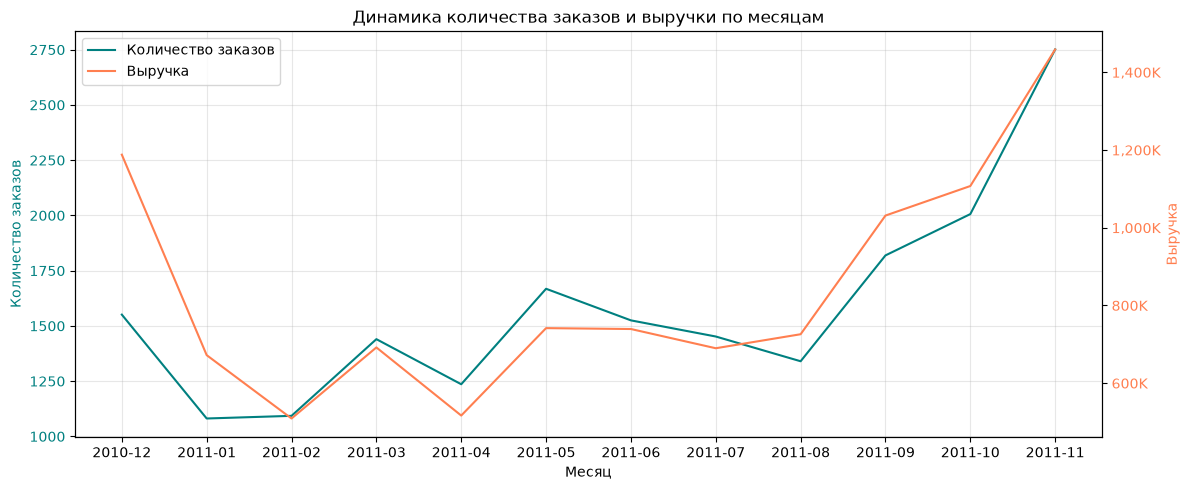

In [52]:
x = orders_per_month['InvoiceDate'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(
    x, orders_per_month['orders_num'],
    color='Teal',
    label='Количество заказов',
)
ax1.set_xlabel('Месяц')
ax1.set_ylabel('Количество заказов', color='Teal')
ax1.tick_params(axis='y', labelcolor='Teal')
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(
    x, revenue_per_month['revenue'],
    color='Coral', 
    label='Выручка',
)
ax2.set_ylabel('Выручка', color='Coral')
ax2.tick_params(axis='y', labelcolor='Coral')
ax2.yaxis.set_major_formatter(lambda v, _: f'{v/1000:,.0f}K')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

plt.title('Динамика количества заказов и выручки по месяцам')
plt.tight_layout()
plt.show()

Картина, которую мы видим на графиках, объяснима для магазина подарков в Европе: рост продаж приходится на сентябрь-ноябрь с пиком в ноябре. Это объясняется, в первую очередь, подготовкой к Рождеству. Частично влияние в сентябре-октябре мог также оказать Хэллоуин. Некоторые подъёмы в марте и мае можно связать с празднованием Дня Матери и Дня Отца.

Кроме того, наблюдается значительное расхождение числа заказов и выручки в декабре 2010 года. Причины этого неочевидны. Рассмотрим метрики декабрьских заказов подробнее для лучшего понимания:

In [53]:
december = df[(df['InvoiceDate'] >= '2010-12-01') & (df['InvoiceDate'] < '2011-01-01')]
order_sizes = (
    december.groupby('Invoice')
    .agg(
        revenue = ('Revenue', 'sum'),
        items_num = ('Quantity', 'sum'))
)
order_sizes.describe()

,revenue,items_num
count,1551.000000,1551.000000
mean,766.012199,347.827208
std,1855.051430,666.989814
min,0.420000,1.000000
25%,174.350000,67.500000
50%,350.090000,168.000000
75%,702.900000,344.000000
max,31770.980000,8560.000000


Мы наблюдаем сильное смещение средних значений выручки и количества товаров в заказе вправо относительно медианы. Это говорит о том, что присутствовало некоторое количество очень крупных заказов, что также подтверждается выдающимся максимальным значением: в одном заказе было продано 8560 товаров на сумму 31770 фунтов стерлингов. Можно предположить, что такие оптовые заказы были сделаны в целях перепродажи товаров в физических магазинах перед Рождеством.

Кратко рассмотрим распределение количества заказов, количество проданных единиц и размер выручки по товарам. Для этого сгруппируем данные по `StockCode`:

In [54]:
revenue_per_product = (
    year_df.groupby('StockCode')
    .agg({
        'Invoice': 'nunique',
        'Quantity': 'sum',
        'Revenue': 'sum'
    }).reset_index()
    .sort_values(by='Revenue', ascending=False)
)

Рассмотрим топ-10 товаров по выручке:

In [55]:
revenue_per_product.head(10)

,StockCode,Invoice,Quantity,Revenue
1235,22423,1929,14487,181956.85
3537,85123A,2132,38669,107336.15
2467,47566,1657,18321,99376.92
3526,85099B,2036,48787,94679.95
1945,23166,233,77826,81448.21
931,22086,1044,18721,63338.93
2665,84879,1408,36647,59439.03
1867,23084,867,26477,57321.97
2531,79321,630,10766,56094.70
1309,22502,463,2035,52012.79


Выручка этих товаров составляет десятки, и даже сотни фунтов стерлингов. Но уже на этом этапе мы видим большую разницу в значениях: выручка первого товара почти вдвое выше выручки второго и в 3,5 раза больше десятого. 

Рассмотрим аутсайдеров: 10 самых нижних записей таблицы:

In [56]:
revenue_per_product.tail(10)

,StockCode,Invoice,Quantity,Revenue
2691,84977,1,1,1.25
236,21009,1,1,1.25
3337,84743C,1,1,1.25
3287,84569C,1,1,1.25
2695,84990,2,2,1.10
3217,84201C,1,5,0.95
3219,84206B,1,5,0.95
2808,90084,1,1,0.85
3097,51014c,1,1,0.83
2567,84227,1,1,0.42


Выручка этих товаров крайне мала: от 0,42 до 1,25 фунтов стерлингов. Эти товары были проданы всего один-два раза, многие из них в единственном экземпляре.

Введём новый столбец с долей выручки товара от общей:

In [57]:
revenue_per_product['rev_share'] = revenue_per_product['Revenue'] / total_revenue * 100
revenue_per_product

,StockCode,Invoice,Quantity,Revenue,rev_share
1235,22423,1929,14487,181956.85,1.806380
3537,85123A,2132,38669,107336.15,1.065582
2467,47566,1657,18321,99376.92,0.986566
3526,85099B,2036,48787,94679.95,0.939937
1945,23166,233,77826,81448.21,0.808579
...,...,...,...,...,...
3217,84201C,1,5,0.95,0.000009
3219,84206B,1,5,0.95,0.000009
2808,90084,1,1,0.85,0.000008
3097,51014c,1,1,0.83,0.000008


Также добавим столбец с кумулятивной долей выручки:

In [58]:
revenue_per_product['cum_rev_share'] = revenue_per_product['rev_share'].cumsum()
revenue_per_product

,StockCode,Invoice,Quantity,Revenue,rev_share,cum_rev_share
1235,22423,1929,14487,181956.85,1.806380,1.806380
3537,85123A,2132,38669,107336.15,1.065582,2.871962
2467,47566,1657,18321,99376.92,0.986566,3.858529
3526,85099B,2036,48787,94679.95,0.939937,4.798466
1945,23166,233,77826,81448.21,0.808579,5.607045
...,...,...,...,...,...,...
3217,84201C,1,5,0.95,0.000009,99.999970
3219,84206B,1,5,0.95,0.000009,99.999979
2808,90084,1,1,0.85,0.000008,99.999988
3097,51014c,1,1,0.83,0.000008,99.999996


Проверим **соответствие данных принципу Парето** (правило 80/20). Он состоит в том, что 80% выручки приносит продажа около 20% товаров.

Разделим все товары на группы:
- **А** - товары, приносящие 80% выручки
- **В** - приносящие следующие 15%
- **С** - приносящие оставшиеся 5%.

In [59]:
def find_abc_group(df):
    """Присваивает группу ABC"""
    prev = df['cum_rev_share'] - df['rev_share']
    if prev < 80:
        return 'A'
    elif prev < 95:
        return 'B'
    else:
        return 'C'

Добавим в таблицу поле с группой:

In [60]:
revenue_per_product['abc_group'] = revenue_per_product.apply(find_abc_group, axis=1)
revenue_per_product.head(5)

,StockCode,Invoice,Quantity,Revenue,rev_share,cum_rev_share,abc_group
1235,22423,1929,14487,181956.85,1.806380,1.806380,A
3537,85123A,2132,38669,107336.15,1.065582,2.871962,A
2467,47566,1657,18321,99376.92,0.986566,3.858529,A
3526,85099B,2036,48787,94679.95,0.939937,4.798466,A
1945,23166,233,77826,81448.21,0.808579,5.607045,A


Проверим, насколько данные о продажах товаров совпадают с принципом Парето:

In [61]:
def display_abc_group_metrics(group):
    """Выводит информацию о группах ABC"""
    
    g_num = (
        revenue_per_product[revenue_per_product['abc_group'] == group]['StockCode']
        .nunique()
    )
    g_num_share = round(g_num / products_num * 100, 2)
    g_rev = (
        round(
            revenue_per_product[revenue_per_product['abc_group']==group]['rev_share']
            .sum(), 2)
    )
    
    return f'Товаров в группе {group}: {g_num}. Это составляет {g_num_share}% ассортимента. Их выручка составляет {g_rev}% от общей.'


for g in ('A', 'B', 'C'):
    print(display_abc_group_metrics(g))

Товаров в группе A: 837. Это составляет 21.4% ассортимента. Их выручка составляет 80.02% от общей.
Товаров в группе B: 982. Это составляет 25.11% ассортимента. Их выручка составляет 14.99% от общей.
Товаров в группе C: 2092. Это составляет 53.49% ассортимента. Их выручка составляет 4.99% от общей.


Размер групп очень близок к каноническому 80/20. Будем считать, что в отношении связи товар-выручка принцип Парето соблюдается.

Посмотрим на товары, характерные для каждой группы. Для этого возьмём три товара из центра каждой группы:

In [62]:
mid_group = (
    revenue_per_product
    .groupby('abc_group', group_keys=False)
    .apply(
        lambda g: g.assign(abc_group=g.name).iloc[len(g)//2 - 1 : len(g)//2 + 2],
        include_groups=False
    )
    .reset_index(drop=True)
)

mid_group

,StockCode,Invoice,Quantity,Revenue,rev_share,cum_rev_share,abc_group
0,23571,221,2629,6024.31,0.059806,63.065437,A
1,23172,287,3693,6021.05,0.059774,63.125211,A
2,21671,363,4362,6001.43,0.059579,63.184791,A
3,15044A,99,461,1442.19,0.014317,89.707145,B
4,22472,91,263,1441.08,0.014306,89.721451,B
5,21872,133,1273,1437.63,0.014272,89.735723,B
6,84569B,19,112,152.15,0.001510,99.464200,C
7,90115,31,61,152.10,0.001510,99.465710,C
8,37479P,32,177,152.01,0.001509,99.467219,C


Мы видим, что значения различаются не только в столбцах `Revenue` и `rev_share`, по которым производилась сортировка и распределение по группам, но и в столбцах с количеством заказов и количеством проданных единиц. Типичный товар группы *А* заказывался сотни раз и за исследуемый период был продан тысячами единиц. Характерный товар группы *В* заказывали несколько десятков раз и его продажи исчисляются сотнями единиц. Типичный товар группы *С* имеет 20-30 заказов за год. 

Построим график для наглядного отображения распределения выручки по товарам:

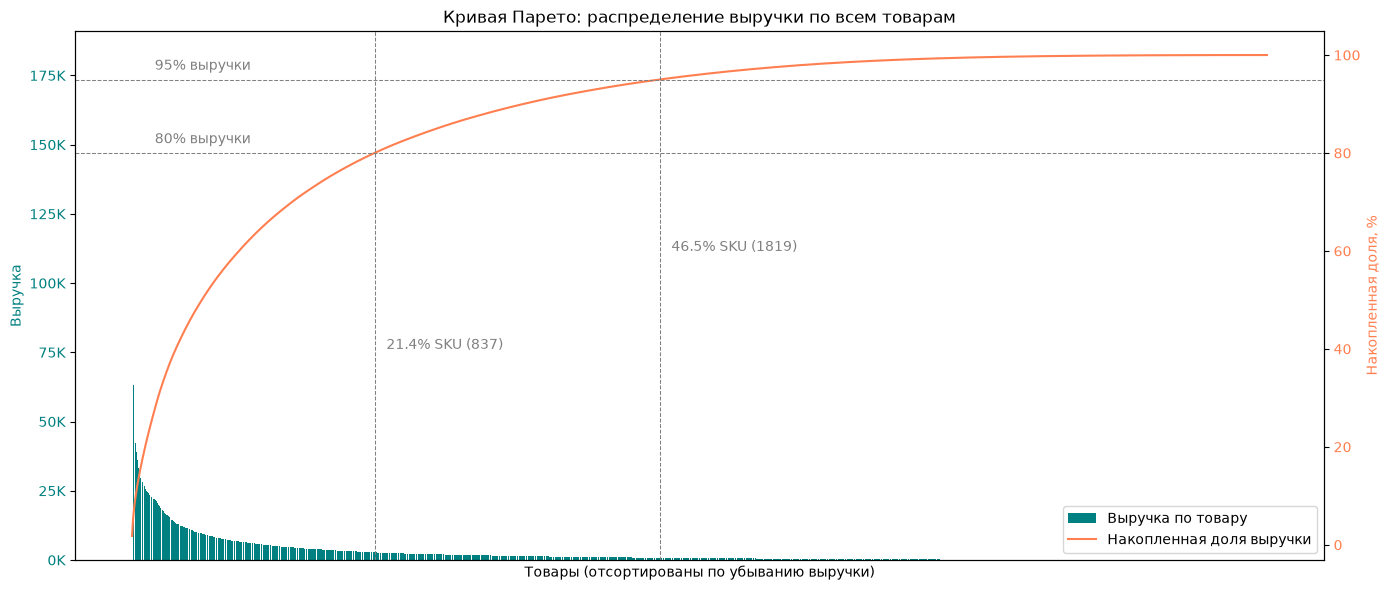

In [131]:
pareto = (
    revenue_per_product[['StockCode', 'Revenue', 'cum_rev_share']]
    .sort_values('Revenue', ascending=False)
    .reset_index(drop=True)
)

fig, ax1 = plt.subplots(figsize=(14, 6))

# Столбцы: выручка по каждому товару
ax1.bar(
    range(len(pareto)), pareto['Revenue'],
    color='Teal', label='Выручка по товару',
)
ax1.set_xlabel('Товары (отсортированы по убыванию выручки)')
ax1.set_ylabel('Выручка', color='Teal')
ax1.tick_params(axis='y', labelcolor='Teal')
ax1.yaxis.set_major_formatter(lambda v, _: f'{v/1000:,.0f}K')
ax1.set_xticks([])

# Линейный график: накопленная доля выручки
ax2 = ax1.twinx()
ax2.plot(
    range(len(pareto)), pareto['cum_rev_share'],
    color='Coral', label='Накопленная доля выручки',
)
ax2.set_ylabel('Накопленная доля, %', color='Coral')
ax2.tick_params(axis='y', labelcolor='Coral')

# Горизонтальная линия: 80% выручки
ax2.axhline(80, color='gray', linestyle='--', linewidth=0.75)
ax2.text(len(pareto) * 0.02, 82, '80% выручки', color='gray', fontsize=10)

# Вертикальная линия: граница товаров группы А
n_80 = (pareto['cum_rev_share'] <= 80).sum() + 1
share_80 = n_80 / len(pareto) * 100
ax2.axvline(n_80, color='gray', linestyle='--', linewidth=0.75)
ax2.text(
    n_80 + len(pareto) * 0.01, 40,
    f'{share_80:.1f}% SKU ({n_80})',
    color='gray', fontsize=10,
)

# Горизонтальная линия: 95% выручки
ax2.axhline(95, color='gray', linestyle='--', linewidth=0.75)
ax2.text(len(pareto) * 0.02, 97, '95% выручки', color='gray', fontsize=10)

# Вертикальная линия: граница товаров группы В
n_95 = (pareto['cum_rev_share'] <= 95).sum() + 1
share_95 = n_95 / len(pareto) * 100
ax2.axvline(n_95, color='gray', linestyle='--', linewidth=0.75)
ax2.text(
    n_95 + len(pareto) * 0.01, 60,
    f'{share_95:.1f}% SKU ({n_95})',
    color='gray', fontsize=10,
)

# Легенда
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='lower right')

plt.title('Кривая Парето: распределение выручки по всем товарам')
plt.tight_layout()
plt.show()

Мы наблюдаем почти идеальное совпадение значений с принципом Парето.

### 3.2 XYZ анализ<a class="anchor" id="xyz"></a>

Перейдём к XYZ-анализу для оценки вариативности физического спроса. Для этого подготовим список из последних 12 полных месяцев датасета:

In [64]:
months = year_df['InvoiceDate'].dt.to_period('M').unique().astype(str)
months

<ArrowStringArray>
['2010-12', '2011-01', '2011-02', '2011-03', '2011-04', '2011-05', '2011-06',
 '2011-07', '2011-08', '2011-09', '2011-10', '2011-11']
Length: 12, dtype: str

Создадим таблицу, в которой для каждого товара подсчитаем количество проданных единиц за каждый месяц из списка:

In [65]:
monthly_unit_sales = (
    year_df
    .assign(Month=year_df['InvoiceDate'].dt.to_period('M'))
    .pivot_table(
        index='StockCode',
        columns='Month',
        values='Quantity',
        aggfunc='sum',
        fill_value=0,
    )
    .reindex(columns=months, fill_value=0)
)

monthly_unit_sales = monthly_unit_sales.reset_index()
monthly_unit_sales.columns.name = None

monthly_unit_sales.head(5)

,StockCode,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11
0,10002,411,340,52,28,189,0,0,0,0,0,0,0
1,10080,0,0,2,0,0,0,60,24,60,60,6,91
2,10120,31,0,30,29,0,3,0,5,35,10,10,49
3,10125,199,213,0,114,82,107,15,177,85,210,51,62
4,10133,164,180,39,83,76,33,526,830,763,207,0,0


Добавим столбец со средним количеством проданных единиц за месяц:

In [66]:
month_cols = monthly_unit_sales.columns.drop('StockCode')

monthly_unit_sales['avg_mon_units']  = monthly_unit_sales[month_cols].mean(axis=1)
monthly_unit_sales.head(5)

,StockCode,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,avg_mon_units
0,10002,411,340,52,28,189,0,0,0,0,0,0,0,85.000000
1,10080,0,0,2,0,0,0,60,24,60,60,6,91,25.250000
2,10120,31,0,30,29,0,3,0,5,35,10,10,49,16.833333
3,10125,199,213,0,114,82,107,15,177,85,210,51,62,109.583333
4,10133,164,180,39,83,76,33,526,830,763,207,0,0,241.750000


Добавим стандартное отклонение:

In [67]:
monthly_unit_sales['std_mon_units']  = monthly_unit_sales[month_cols].std(axis=1)
monthly_unit_sales.head(5)

,StockCode,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,avg_mon_units,std_mon_units
0,10002,411,340,52,28,189,0,0,0,0,0,0,0,85.000000,146.792990
1,10080,0,0,2,0,0,0,60,24,60,60,6,91,25.250000,33.092501
2,10120,31,0,30,29,0,3,0,5,35,10,10,49,16.833333,16.953591
3,10125,199,213,0,114,82,107,15,177,85,210,51,62,109.583333,74.687784
4,10133,164,180,39,83,76,33,526,830,763,207,0,0,241.750000,296.011095


Рассчитаем на основе этих столбцов коэффициент вариации CV, разделив стандартное отклонение на среднее количество проданных единиц в месяц:

In [68]:
monthly_unit_sales['cv_mon_units']  = (
    monthly_unit_sales['std_mon_units'] / monthly_unit_sales['avg_mon_units']
)
monthly_unit_sales.head(5)

,StockCode,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,avg_mon_units,std_mon_units,cv_mon_units
0,10002,411,340,52,28,189,0,0,0,0,0,0,0,85.000000,146.792990,1.726976
1,10080,0,0,2,0,0,0,60,24,60,60,6,91,25.250000,33.092501,1.310594
2,10120,31,0,30,29,0,3,0,5,35,10,10,49,16.833333,16.953591,1.007144
3,10125,199,213,0,114,82,107,15,177,85,210,51,62,109.583333,74.687784,0.681562
4,10133,164,180,39,83,76,33,526,830,763,207,0,0,241.750000,296.011095,1.224451


Используя это значение, **присвоим каждому товару группу**:
- **X** - товары с CV менее 0,5. Это товары с относительно стабильным спросом.
- **Y** - CV больше 0,5, и меньше 1. Спрос на эти товары умеренно вариативен.
- **Z** - CV больше 1. На эти товары спрос сильно вариативен.

In [69]:
def find_xyz_group(df):
    """Присваивает группу XYZ"""
    
    if df['cv_mon_units'] <= 0.5:
        return 'X'
    elif df['cv_mon_units'] <= 1:
        return 'Y'
    else:
        return 'Z'

In [70]:
monthly_unit_sales['xyz_group'] = monthly_unit_sales.apply(find_xyz_group, axis=1)
monthly_unit_sales.head(5)

,StockCode,2010-12,2011-01,2011-02,2011-03,2011-04,2011-05,2011-06,2011-07,2011-08,2011-09,2011-10,2011-11,avg_mon_units,std_mon_units,cv_mon_units,xyz_group
0,10002,411,340,52,28,189,0,0,0,0,0,0,0,85.000000,146.792990,1.726976,Z
1,10080,0,0,2,0,0,0,60,24,60,60,6,91,25.250000,33.092501,1.310594,Z
2,10120,31,0,30,29,0,3,0,5,35,10,10,49,16.833333,16.953591,1.007144,Z
3,10125,199,213,0,114,82,107,15,177,85,210,51,62,109.583333,74.687784,0.681562,Y
4,10133,164,180,39,83,76,33,526,830,763,207,0,0,241.750000,296.011095,1.224451,Z


Изучим распределение товаров по группам XYZ:

In [71]:
def display_xyz_group_metrics(group):
    """Выводит информацию о группах XYZ"""
    
    g_num = monthly_unit_sales[monthly_unit_sales['xyz_group']==group]['StockCode'].nunique()
    g_num_share = round(g_num / products_num * 100, 2)
    
    return f'Товаров в группе {group}: {g_num}. Это составляет {g_num_share}% ассортимента.'


for g in ('X', 'Y', 'Z'):
    print(display_xyz_group_metrics(g))

Товаров в группе X: 312. Это составляет 7.98% ассортимента.
Товаров в группе Y: 1046. Это составляет 26.75% ассортимента.
Товаров в группе Z: 2553. Это составляет 65.28% ассортимента.


Мы видим, что большая часть товаров имеет выраженную вариативность спроса. Это, в целом, ожидаемо, учитывая специфику магазина подарков.

Кроме действительно непредсказуемых товаров в категорию *Z* также могли попасть недавно появившиеся в ассортименте товары и сезонные товары, имеющие высокие продажи несколько месяцев в году, но невостребованные в другое время. Такие товары необходимо отметить как требующие особой стратегии управления.

Сохраним количество товаров в группе *Z* для отслеживания изменений:

In [72]:
z_num_before_correction = (
    monthly_unit_sales[monthly_unit_sales['xyz_group'] == 'Z']['StockCode']
    .nunique()
)

Для начала найдём для каждого товара дату первой продажи по полному очищенному датафрейму:

In [73]:
first_sale = (
    df_cleaned
    .groupby('StockCode')['InvoiceDate']
    .min()
    .rename('first_sale_date')
    .reset_index()
)
first_sale.head(5)

,StockCode,first_sale_date
0,10002,2009-12-01
1,10080,2009-12-02
2,10109,2009-12-03
3,10120,2009-12-01
4,10125,2009-12-01


Добавим её отдельным столбцом в таблицу с помесячными продажами товаров:

In [74]:
monthly_unit_sales = monthly_unit_sales.merge(first_sale, on='StockCode', how='left')

Определим дату за полгода до конца исследуемого периода. Товары, первая продажа которых состоялась в эту дату или позже, будем считать новыми.

In [75]:
last_date = year_df['InvoiceDate'].max()
six_months_before = last_date - relativedelta(months=6)

Добавим новый столбец `flag` и внесем в него для таких товаров метку `new`:

In [76]:
monthly_unit_sales['flag'] = ''
new_mask = monthly_unit_sales['first_sale_date'] >= six_months_before
monthly_unit_sales.loc[new_mask, 'flag'] = 'new'

Посмотрим, сколько товаров получили метку:

In [77]:
def describe_flag(flag):
    """Выводит информацию о метках"""
    
    f_num = monthly_unit_sales[monthly_unit_sales['flag'] == flag]['StockCode'].nunique()
    f_num_share = round(f_num / products_num * 100, 2)
    result = [f'Товаров с меткой {flag}: {f_num}. Это составляет {f_num_share}% ассортимента.\n']
    
    for g in ('X', 'Y', 'Z'):
        f_g_num = (
            monthly_unit_sales[(
                monthly_unit_sales['flag']==flag
            ) & (
                monthly_unit_sales['xyz_group']==g
            )]['StockCode']
            .nunique()
        )
        result.append(f'Из них в группе {g}: {f_g_num}.\n')
    
    return result


print(*describe_flag('new'))

Товаров с меткой new: 450. Это составляет 11.51% ассортимента.
 Из них в группе X: 0.
 Из них в группе Y: 0.
 Из них в группе Z: 450.



Вполне ожидаемо, что такие товары попали в группу *Z*: по ним есть информация по заказам всего за 1-6 месяцев, а за остальные месяцы продажи нулевые. Реальная ценность таких товаров для бизнеса пока неясна: со временем они могут перейти в другую группу. Метка сигнализирует о том, что, хотя спрос на эти товары нестабилен, принимать решение об их удалении из ассортимента преждевременно.

Для товаров со сроком продаж от полугода до года выявить сезонность с большой долей достоверности не представляется возможным. Даже если продажи этих товаров сконцентрированы в нескольких месяцах, причина может быть не в сезоне, а, например, в эффекте новинки или проведении маркетинговых акций (в том числе нацеленных на ознакомление клиентов с новыми позициями).

По этой причине было решено для таких товаров присвоить метку `young` и не менять группу.

In [78]:
one_year_before = last_date - relativedelta(months=12)

young_mask = (
    (monthly_unit_sales['first_sale_date'] >= one_year_before) &
    (monthly_unit_sales['first_sale_date'] < six_months_before)
)

monthly_unit_sales.loc[young_mask, 'flag'] = 'young'

Проверим, сколько товаров получили метку:

In [79]:
print(*describe_flag('young'))

Товаров с меткой young: 225. Это составляет 5.75% ассортимента.
 Из них в группе X: 2.
 Из них в группе Y: 87.
 Из них в группе Z: 136.



Для выявления сезонности товаров, чей срок продажи составляет более 12 месяцев, мы можем использовать данные за последние 24 месяца продаж, сравнить их помесячно и посчитать для пар месяцев коэффициент корреляции Спирмена: он покажет наличие (или отсутствие) связи между рангами месяцев по продажам, при этом позволяет анализировать ненормально распределенные данные и более устойчив к выбросам, чем коэффициент корреляции Пирсона.

Определим товары со сроком продажи более года:

In [80]:
more_than_year_old = monthly_unit_sales[
    (monthly_unit_sales['xyz_group'] == 'Z') &
    (monthly_unit_sales['first_sale_date'] < one_year_before)
]['StockCode']

Отберем для этих товаров все данные по продажам за последние полные 24 месяца (с 1 декабря 2009 г. по 30 ноября 2011 г.):

In [81]:
two_years_df = df_cleaned[
    df_cleaned['StockCode'].isin(more_than_year_old) &
    (df_cleaned['InvoiceDate'] >= '2009-12-01') &
    (df_cleaned['InvoiceDate'] <= '2011-11-30')
].copy()

Добавим столбец, обозначающий год сравнения:
- в Y1 попадут данные за период с 1 декабря 2009 г. по 30 ноября 2010 г.
- в Y2 - с 1 декабря 2010 г. по 30 ноября 2011 г.

In [82]:
period_1_end = pd.Timestamp('2010-11-30')

two_years_df['Year'] = np.where(
    two_years_df['InvoiceDate'] <= period_1_end,
    'Y1',
    'Y2',
)

two_years_df['Month'] = two_years_df['InvoiceDate'].dt.month

Создадим таблицу, в которой для каждого товара будет подсчитано количество проданных единиц за каждый месяц периода:

In [83]:
seasonal_data = (
    two_years_df
    .groupby(['StockCode', 'Year', 'Month'])['Quantity']
    .sum()
    .unstack(level='Year', fill_value=0)
)

seasonal_data.head(12)

Year               Y1   Y2
StockCode Month           
10002     1       291  340
          2       257   52
          3       642   28
          4      1132  189
          5      1465    0
          6       463    0
          7       512    0
          8       586    0
          9       242    0
          10     1046    0
          11      964    0
          12      216  411

Создадим временную таблицу `corr_df` и **подсчитаем корреляцию Спирмена** по двум годам. В качестве страховки функция подсчитаем не только прямую корреляцию, но и сдвинутую циклически на один месяц в обе стороны, ведь смещение пика продаж для сезонных товаров на один месяц вполне возможно при сезоне длиной в 3-4 месяца (например, рождественском). Результатом станет наибольшее значение. Также функция вернёт NaN, если данных недостаточно (менее 12 строк) или все данные в одном году совпадают и стандартное отклонение равно нулю.

In [84]:
def shifted_spearman(group, max_lag=1):
    """Считает корреляцию Спирмена между годами по месяцам со сдвигом -1, 0, 1. Возвращает наибольшую"""
    
    if len(group) < 12:
        return np.nan

    s1, s2 = group['Y1'], group['Y2']
    if s1.std() == 0 or s2.std() == 0:
        return np.nan

    correlations = []
    for lag in range(-max_lag, max_lag + 1):
        shifted = pd.Series(np.roll(s2.values, lag), index=s2.index)
        if shifted.std() == 0:
            continue
        correlations.append(s1.corr(shifted, method='spearman'))

    return max(correlations) if correlations else np.nan


corr_df = (
    seasonal_data
    .groupby('StockCode', group_keys=False)
    .apply(shifted_spearman)
    .rename('season_corr')
    .reset_index()
)

corr_df.head(5)

,StockCode,season_corr
0,10002,0.109172
1,10080,NaN
2,10120,0.638473
3,10133,-0.007005
4,15030,NaN


Присоединим столбец со значением корреляции к основной таблице XYZ-анализа:

In [85]:
monthly_unit_sales = (
    monthly_unit_sales
    .merge(
        corr_df[['StockCode', 'season_corr']],
        on='StockCode',
        how='left')
)

Скорректируем группы в соответствии со значением корреляции:
- при значении от 0,7  и выше имеет место высокая корреляция продаж по месяцам между годами. Такие товары переносятся в группу *Y* по причине того, что вариативность спроса объясняется сезонностью и является предсказуемой. Также таким товарам присваивается метка `seasonal`: они требуют иного подхода к управлению запасами, нежели товары с более стабильным спросом;
- при корреляции от 0,5 до 0,7 наблюдается умеренная корреляция. Такие товары остаются в группе *Z* и получают метку `seasonal`;
- при значении ниже 0,5 товары остаются в своей группе. Это товары, спрос на которые хаотичен и непредсказуем;
- товары, по которым корреляцию посчитать не удалось, также остаются в своей группе без метки.

In [86]:
seasonal_y = (
    (monthly_unit_sales['xyz_group'] == 'Z') &
    (monthly_unit_sales['season_corr'] > 0.7)
)

seasonal_z = (
    (monthly_unit_sales['xyz_group'] == 'Z') &
    (monthly_unit_sales['season_corr'] > 0.5) &
    (monthly_unit_sales['season_corr'] <= 0.7)
)

monthly_unit_sales.loc[seasonal_y, 'xyz_group'] = 'Y'
monthly_unit_sales.loc[seasonal_y, 'flag'] = 'seasonal'
monthly_unit_sales.loc[seasonal_z, 'flag'] = 'seasonal'

Посмотрим, как изменилось соотношение групп *Y* и *Z*:

In [87]:
for g in ('Y', 'Z'):
    print(display_xyz_group_metrics(g)) 

Товаров в группе Y: 1158. Это составляет 29.61% ассортимента.
Товаров в группе Z: 2441. Это составляет 62.41% ассортимента.


In [88]:
z_num_after_seasonal_correction = (
    monthly_unit_sales[monthly_unit_sales['xyz_group']=='Z']['StockCode']
    .nunique()
)
print(f'Товаров переведено в группу Y: {z_num_before_correction - z_num_after_seasonal_correction}')

Товаров переведено в группу Y: 112


Проверим, сколько товаров в группе *Z* получили сезонную метку:

In [89]:
print(*describe_flag('seasonal'))

Товаров с меткой seasonal: 280. Это составляет 7.16% ассортимента.
 Из них в группе X: 0.
 Из них в группе Y: 112.
 Из них в группе Z: 168.



Таким образом, картина распределения товаров среди групп по стабильности спроса выглядит так:

In [90]:
for g in ('X', 'Y', 'Z'):
    print(display_xyz_group_metrics(g))

Товаров в группе X: 312. Это составляет 7.98% ассортимента.
Товаров в группе Y: 1158. Это составляет 29.61% ассортимента.
Товаров в группе Z: 2441. Это составляет 62.41% ассортимента.


Среди ассортимента встречаются товары, требующие иной стратегии управления, нежели группа в целом. Они помечены флагами и распределены между группами следующим образом:

In [91]:
for f in ('new', 'young', 'seasonal'):
    print(*describe_flag(f))

Товаров с меткой new: 450. Это составляет 11.51% ассортимента.
 Из них в группе X: 0.
 Из них в группе Y: 0.
 Из них в группе Z: 450.

Товаров с меткой young: 225. Это составляет 5.75% ассортимента.
 Из них в группе X: 2.
 Из них в группе Y: 87.
 Из них в группе Z: 136.

Товаров с меткой seasonal: 280. Это составляет 7.16% ассортимента.
 Из них в группе X: 0.
 Из них в группе Y: 112.
 Из них в группе Z: 168.



## 3.3 Объединённый анализ ABC/XYZ и рекомендации по выбору стратегии управления<a class="anchor" id="abc_xyz"></a>

Посчитаем для каждого товара дополнительные метрики: количество проданных единиц, заказов, активных месяцев, покупателей, а также среднюю цену за последние 12 полных месяцев. Они понадобятся на этапе выбора стратегии управления запасами.

In [92]:
monthly_unit_sales['units'] = monthly_unit_sales[month_cols].sum(axis=1)
monthly_unit_sales['active_months'] = (monthly_unit_sales[month_cols] > 0).sum(axis=1)

In [93]:
orders_customers = (
    year_df
    .groupby('StockCode')
    .agg(
        orders = ('Invoice', 'nunique'),
        customers = ('Customer ID', 'nunique'),
    )
    .reset_index()
)

In [94]:
mean_price = (
    year_df.groupby('StockCode')
    .agg(
        total_revenue  = ('Revenue', 'sum'),
        total_quantity = ('Quantity', 'sum'),
    )
    .reset_index()
)
mean_price['avg_price'] = (mean_price['total_revenue'] / mean_price['total_quantity']).round(2)
mean_price = mean_price[['StockCode', 'avg_price']]

Объединим таблицы  с метриками по `StockCode`:

In [95]:
xyz_table = monthly_unit_sales[['StockCode', 'xyz_group', 'flag', 'units', 'active_months']].copy()

In [96]:
abc_table = (
    revenue_per_product[['StockCode', 'abc_group', 'Revenue']]
    .groupby('StockCode', as_index=False)
    .agg(
        abc_group = ('abc_group', 'first'),
        revenue   = ('Revenue', 'sum'),
    )
)

In [97]:
abc_xyz = (
    xyz_table
    .merge(abc_table, on='StockCode', how='left')
    .merge(orders_customers, on='StockCode', how='left')
    .merge(mean_price, on='StockCode', how='left')
)

In [98]:
abc_xyz['abc_xyz'] = abc_xyz['abc_group'].astype(str) + abc_xyz['xyz_group'].astype(str)

In [99]:
abc_xyz['orders'] = abc_xyz['orders'].fillna(0).astype(int)
abc_xyz['customers'] = abc_xyz['customers'].fillna(0).astype(int)

In [100]:
abc_xyz = abc_xyz[
    ['StockCode', 'abc_xyz', 'flag', 'units', 'orders',
     'revenue', 'avg_price', 'active_months',
     'customers', 'abc_group', 'xyz_group']
]

Мы сформировали таблицу, в которой каждому товару <u>присвоена ABC/XYZ группа</u>, а также посчитаны основные метрики:

In [101]:
abc_xyz.head(5)

,StockCode,abc_xyz,flag,units,orders,revenue,avg_price,active_months,customers,abc_group,xyz_group
0,10002,BZ,,1020,71,911.28,0.89,5,40,B,Z
1,10080,CZ,,303,22,119.09,0.39,7,19,C,Z
2,10120,CZ,seasonal,202,28,42.42,0.21,9,25,C,Z
3,10125,BY,,1315,89,1012.61,0.77,11,48,B,Y
4,10133,BZ,,2901,196,1573.93,0.54,10,101,B,Z


Добавим вспомогательные бинарные столбцы с метками:

In [102]:
abc_xyz['is_new'] = (abc_xyz['flag'] == 'new').astype(bool)
abc_xyz['is_young'] = (abc_xyz['flag'] == 'young').astype(bool)
abc_xyz['is_seasonal'] = (abc_xyz['flag'] == 'seasonal').astype(bool)
abc_xyz['no_flag'] = (abc_xyz['flag'] == '').astype(bool)

Агрегируем эти данные для подсчета метрик по объединенным группам:

In [103]:
abc_xyz_summary = (
    abc_xyz
    .groupby(['abc_xyz'])
    .agg(
        products = ('StockCode', 'nunique'),
        units = ('units', 'sum'),
        revenue = ('revenue', 'sum'),
        orders = ('orders', 'nunique'),
        avg_price = ('avg_price', 'mean'),
        customers = ('customers', 'nunique'),
        active_months = ('active_months', 'mean'),
        new   = ('is_new', 'sum'),
        young = ('is_young', 'sum'),
        seasonal = ('is_seasonal', 'sum'),
        no_flag  = ('no_flag', 'sum')
    )
    .reset_index()
)

abc_xyz_summary['revenue_share'] = (
    abc_xyz_summary['revenue'] / abc_xyz_summary['revenue'].sum() * 100
).round(2)

In [104]:
abc_xyz_summary

,abc_xyz,products,units,revenue,orders,avg_price,customers,active_months,new,young,seasonal,no_flag,revenue_share
0,AX,209,1351775,2299534.95,188,3.320718,153,11.990431,0,2,0,207,22.83
1,AY,362,1541641,3811902.70,276,5.146464,221,11.323204,0,55,36,271,37.84
2,AZ,266,809889,1948920.74,200,5.336316,173,7.454887,100,51,20,95,19.35
3,BX,88,173240,142610.62,79,2.043750,62,11.977273,0,0,0,88,1.42
4,BY,399,540515,622175.58,193,2.754085,138,11.578947,0,27,45,327,6.18
5,BZ,495,536044,744870.43,190,3.549152,131,7.688889,150,48,54,243,7.39
6,CX,15,13375,8119.05,14,0.955333,12,12.000000,0,0,0,15,0.08
7,CY,397,154767,156637.43,130,2.449899,82,10.831234,0,5,31,361,1.56
8,CZ,1680,323462,338236.38,121,3.530643,79,5.357738,200,37,94,1349,3.36


Построим тепловую карту объединённых групп по количеству SKU:

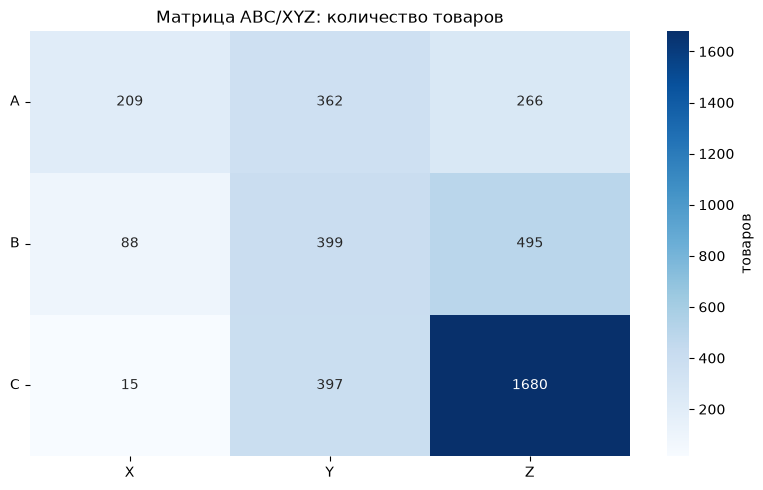

In [105]:
heat = abc_xyz.pivot_table(
    index='abc_group', columns='xyz_group',
    values='StockCode', aggfunc='nunique', fill_value=0,
).reindex(index=['A', 'B', 'C'], columns=['X', 'Y', 'Z'], fill_value=0)

plt.figure(figsize=(8, 5))
ax = sns.heatmap(
    heat,
    annot=True,
    fmt='d',
    cmap='Blues',
    cbar_kws={'label': 'товаров'},
)

ax.set_xlabel('')
ax.set_ylabel('')

ax.set_yticklabels(ax.get_yticklabels(), rotation=0, va='center')

plt.title('Матрица ABC/XYZ: количество товаров')
plt.tight_layout()
plt.show()

Построим читаемую матрицу с основными метриками по объединенным группам:

In [106]:
def format_html(row):
    """Строит матрицу в html-формате"""

    lines = [
        f"<b>% выручки:</b> {row['revenue_share']:.2f}<br>",
        f"<b>выручка:</b> {row['revenue']:,.0f}<br>",
        f"<b>товаров:</b> {row['products']}<br>",
        f"<b>единиц:</b> {row['units']:,}<br>",
        f"<b>заказов:</b> {row['orders']:,}<br>",
        f"<b>покупателей:</b> {row['customers']}<br>",
        f"<b>месяцев продаж (сред.):</b> {row['active_months']:.2f}<br>",
        f"<b>средняя цена единицы:</b> {row['avg_price']:.2f}<br>",
    ]

    flag_parts = []
    if row['seasonal'] > 0:
        flag_parts.append(f"seasonal: {row['seasonal']}")
    if row['young'] > 0:
        flag_parts.append(f"young: {row['young']}")
    if row['new'] > 0:
        flag_parts.append(f"new: {row['new']}")
  # кол-во товаров без флага выводим только если в группе есть товары с флагом
    if row['no_flag'] > 0 and flag_parts:
        flag_parts.append(f"без метки: {row['no_flag']}")

    if flag_parts:
        lines.append(f"<b>метки:</b> {', '.join(flag_parts)}<br>")

    return ''.join(lines)


abc_xyz_summary['abc_group'] = abc_xyz_summary['abc_xyz'].str[0]
abc_xyz_summary['xyz_group'] = abc_xyz_summary['abc_xyz'].str[1]
abc_xyz_summary['cell_html'] = abc_xyz_summary.apply(format_html, axis=1)

html_matrix = (
    abc_xyz_summary
    .pivot(index='abc_group', columns='xyz_group', values='cell_html')
    .reindex(index=['A', 'B', 'C'], columns=['X', 'Y', 'Z'])
)

HTML(html_matrix.to_html(escape=False))

xyz_group,X,Y,Z
abc_group,,,
A,"% выручки: 22.83выручка: 2,299,535товаров: 209единиц: 1,351,775заказов: 188покупателей: 153месяцев продаж (сред.): 11.99средняя цена единицы: 3.32метки: young: 2, без метки: 207","% выручки: 37.84выручка: 3,811,903товаров: 362единиц: 1,541,641заказов: 276покупателей: 221месяцев продаж (сред.): 11.32средняя цена единицы: 5.15метки: seasonal: 36, young: 55, без метки: 271","% выручки: 19.35выручка: 1,948,921товаров: 266единиц: 809,889заказов: 200покупателей: 173месяцев продаж (сред.): 7.45средняя цена единицы: 5.34метки: seasonal: 20, young: 51, new: 100, без метки: 95"
B,"% выручки: 1.42выручка: 142,611товаров: 88единиц: 173,240заказов: 79покупателей: 62месяцев продаж (сред.): 11.98средняя цена единицы: 2.04","% выручки: 6.18выручка: 622,176товаров: 399единиц: 540,515заказов: 193покупателей: 138месяцев продаж (сред.): 11.58средняя цена единицы: 2.75метки: seasonal: 45, young: 27, без метки: 327","% выручки: 7.39выручка: 744,870товаров: 495единиц: 536,044заказов: 190покупателей: 131месяцев продаж (сред.): 7.69средняя цена единицы: 3.55метки: seasonal: 54, young: 48, new: 150, без метки: 243"
C,"% выручки: 0.08выручка: 8,119товаров: 15единиц: 13,375заказов: 14покупателей: 12месяцев продаж (сред.): 12.00средняя цена единицы: 0.96","% выручки: 1.56выручка: 156,637товаров: 397единиц: 154,767заказов: 130покупателей: 82месяцев продаж (сред.): 10.83средняя цена единицы: 2.45метки: seasonal: 31, young: 5, без метки: 361","% выручки: 3.36выручка: 338,236товаров: 1680единиц: 323,462заказов: 121покупателей: 79месяцев продаж (сред.): 5.36средняя цена единицы: 3.53метки: seasonal: 94, young: 37, new: 200, без метки: 1349"


#### Сформулируем стратегию управления для каждой группы:<a class="anchor" id="strategy"></a>
- **AX**: товары с высокой выручкой и стабильным спросом. Необходимо регулярно отслеживать наличие и своевременно заказывать, важно избегать ситуаций отсутствия на складе. Рекомендуем иметь запас на 15–20% больший, чем ожидаемый спрос. Группу товаров с меткой `young` уточнить через полгода;
- **AY**: товары с высокой выручкой при некоторых колебаниях в спросе. Рекомендуется постоянное наличие для товаров без метки. Для товаров с меткой `seasonal` - минимальный запас, увеличение перед сезоном. Группу товаров с меткой `young` уточнить через полгода, в остальном та же стратегия, что и для товаров без метки;
- **AZ**: товары с высокой выручкой и хаотичным спросом. Самая высокая средняя цена единицы. Рекомендуется закупка мелкими партиями, возможно, под заказ от оптовых клиентов. С меткой `seasonal` - закупка под сезон, без запаса в остальное время. С меткой `young` - уточнить группу через полгода. С меткой *new* - перспективные новички, уточнить группу через полгода и через год;
- **BX**: товары со средней выручкой и стабильным спросом. Ни одного сезонного или нового товара, все проверены временем. Необходимо постоянное наличие с небольшим (10%) запасом;
- **BY**: товары со средней выручкой и колеблющимся спросом. Для товаров без метки рекомендуется постоянное наличие, примерно равное спросу. Товары с меткой `seasonal` - закупка только под сезон. Группу товаров с меткой `young` уточнить через полгода;
- **BZ**: товары со средней выручкой и хаотичным спросом. Для товаров без метки рекомендуется закупка под спрос без запаса. С меткой `seasonal` - закупка под сезон, также без запаса. Товары с метками `young` и особенно `new` имеют шанс изменить группу на более высокую или более низкую. Пока не менять для них стратегию. Для всех товаров стоит регулярно уточнять группу;
- **CX**: товары со стабильным спросом и низкой выручкой. Самая маленькая группа: всего 15 товаров и 12 покупателей, но все из них продаются каждый месяц. Стоит проверить, не идут ли эти товары в одной корзине с AX и BX как дополнение. В этом случае можно повысить их продажи, рекомендуя их при заказе связанных товаров. Рекомендуется постоянное наличие с минимальным запасом;
- **CY**: товары с низкой выручкой и вариативным спросом. Стоит проверить роль в корзине, так же, как и с CX. Для товаров без метки закупка под спрос без запаса. Для сезонных - закупка под сезон без запаса;
- **CZ**: товары с низкой выручкой и непредсказуемым спросом. Самая большая группа: 1680 товаров. Сезонные товары рекомендуется закупать под сезон без запаса. Стратегию для новых и молодых товаров оставить без изменения и проверить через полгода: они могут вырасти до более высокой группы. Среди товаров без метки ниже будут выбраны кандидаты на удаление из ассортимента.

## 4. Формирование списка кандидатов на удаление<a class="anchor" id="remove"></a>

Для формирования списка кандидатов на удаление из ассортимента отберем товары группы CZ без меток: <u>не новые, не молодые и не сезонные</u>.

In [107]:
no_flag_cz = (
    abc_xyz[(abc_xyz['abc_xyz'] == 'CZ')
    & (abc_xyz['flag'] == '')].copy()
)

Оставим только полезные для дальнейшей работы столбцы:

In [108]:
no_flag_cz = (no_flag_cz[
              ['StockCode', 'units', 'orders',
               'revenue', 'active_months',
               'customers']]
              .copy()
)

Ознакомимся со статистикой этих товаров:

In [109]:
print(f'Товаров CZ без метки: {len(no_flag_cz)}')
print(f'Это составляет {len(no_flag_cz) / products_num * 100:.1f}% ассортимента')
print(f"Суммарная выручка: {no_flag_cz['revenue'].sum():,.0f} £"
      f"({no_flag_cz['revenue'].sum()/abc_xyz['revenue'].sum()*100:.2f}% от общей)")

Товаров CZ без метки: 1349
Это составляет 34.5% ассортимента
Суммарная выручка: 242,784 £(2.41% от общей)


Товаров в этой группе очень много: чуть больше трети ассортимента. Для обоснованного выбора товаров для сокращения подсчитаем своеобразный **"рейтинг"** товара. Для этого мы присвоим каждому товару из списка ранг по сумме пяти показателей: выручки, количества заказов, количества проданных единиц, количества покупателей и количества активных месяцев. По каждой из этих метрик товару будет присвоен равномерно распределённый ранг от 1 до n (равного количеству товаров в выборке). Товар с наибольшим значением выручки получит наибольший ранг и т.д. При этом товары с одинаковым значением метрики получат одинаковый ранг. Равномерное распределение введено для того, чтобы количество активных месяцев продаж влияло на итоговое суммарное значение так же, как и остальные метрики, несмотря на то, что для этого показателя возможно всего 11 уникальных значений.

In [110]:
def linear_rank(series):
    """Присваивает линейный ранг"""

    unique_values = sorted(series.unique())
    k = len(unique_values)
    n = len(series)

    if k == 1:
        return pd.Series(1, index=series.index)

    rank_dict = {
        value: i / (k - 1) * (n - 1) + 1
        for i, value in enumerate(unique_values)
    }

    return series.map(rank_dict)

Применим функцию и посмотрим на самые слабые по рейтингу товары:

In [111]:
no_flag_cz['rating'] = (
    round(
    linear_rank(no_flag_cz['revenue']) +
    linear_rank(no_flag_cz['orders']) +
    linear_rank(no_flag_cz['units']) +
    linear_rank(no_flag_cz['customers']) +
    linear_rank(no_flag_cz['active_months']), 2)
)


no_flag_cz = no_flag_cz.sort_values('rating', ascending=True).reset_index(drop=True)
no_flag_cz.head(10)

,StockCode,units,orders,revenue,active_months,customers,rating
0,21009,1,1,1.25,1,0,9.34
1,84977,1,1,1.25,1,0,9.34
2,90092,1,1,1.66,1,0,12.60
3,21491,1,1,1.95,1,0,14.78
4,20860,1,1,2.10,1,0,18.03
5,84510e,1,1,2.46,1,0,21.29
6,82613a,1,1,2.46,1,0,21.29
7,85179a,1,1,2.46,1,0,21.29
8,90112,2,1,2.10,1,0,21.43
9,90037A,1,1,2.48,1,0,23.47


Мы видим, что во главе списка неудачных товаров оказались те, которые были проданы всего один раз в количестве 1-2 штук неидентифицируемым покупателем. Такие товары определённо зря занимают место на складе. Посмотрим на наиболее полезные товары в выборке. Они расположены в конце таблицы:

In [112]:
no_flag_cz.tail(10)

,StockCode,units,orders,revenue,active_months,customers,rating
1339,22266,1812,88,582.06,11,65,5938.64
1340,22096,1153,113,506.98,11,87,6130.60
1341,22533,1927,86,703.27,12,66,6136.64
1342,21159,1107,119,604.20,12,72,6241.58
1343,21163,1220,127,717.90,11,86,6314.27
1344,22403,1313,122,701.19,12,70,6329.88
1345,22522,931,127,773.44,12,99,6460.62
1346,21084,2542,176,753.82,11,88,6516.88
1347,22097,1405,140,676.36,12,100,6539.53
1348,21158,1456,161,792.98,12,101,6642.17


Эти товары показывают совсем другую картину: почти все они были проданы в количестве более тысячи единиц за год  и принесли компании от 506 до 792 фунтов стерлингов. Они востребованы среди десятков покупателей и продавались 11-12 месяцев. Такие товары однозначно не заслуживают сокращения.

#### Выбор порога доли исключаемых товаров

Целевое значение количества исключаемых товаров составляет 20% ассортимента. Но по соотношению количества исключаемых товаров и размера гипотетической потерянной прибыли эта доля может оказаться неоптимальной. Проведем <u>анализ чувствительности</u> для разных порогов удаления: 15%, 17,5%, 20%, 22,5% и 25%. Проверим количество товаров, попадающих в список на сокращение, их выручку, долю от общей выручки, а также среднюю выручку каждого товара, добавленного в список на этом пороге.

In [113]:
thresholds = [0.15, 0.175, 0.20, 0.225, 0.25]

rows = []
prev_n = 0
prev_rev = 0

for t in thresholds:
    scu_num = int(products_num * t)
    n = min(scu_num, len(no_flag_cz))
    subset = no_flag_cz.head(n)
    
    rev = subset['revenue'].sum()
    rev_share = rev / total_revenue * 100
    delta_n = n - prev_n
    delta_rev = rev - prev_rev
    avg_rev_per_scu = delta_rev / delta_n

    rows.append({
        'threshold': f'{t * 100:.1f}%',
        'products_num': n,
        'revenue_lost': rev,
        'revenue_perc': rev_share.round(2),
        'avg_rev_per_added': f'{avg_rev_per_scu:.2f}'
    })

    prev_n = n
    prev_rev = rev

sensitivity = pd.DataFrame(rows)
sensitivity

,threshold,products_num,revenue_lost,revenue_perc,avg_rev_per_added
0,15.0%,586,19960.91,0.20,34.06
1,17.5%,684,30740.73,0.31,110.00
2,20.0%,782,42794.95,0.42,123.00
3,22.5%,879,59500.28,0.59,172.22
4,25.0%,977,81713.64,0.81,226.67


Мы можем наблюдать скачок средней прибыли добавленного товара при переходе от порога 15% к 17,5%: с 34 до 110 £. Это говорит о том, что 586 товаров, попадающих под сокращение при выборе порога в 15% - "мусорные" товары, мертвым грузом лежащие на складе. При этом утерянная прибыль растёт незначительно: с 0,2% до 0,31%. Ещё один скачок роста средней прибыли добавленного товара можно наблюдать при переходе от 20% к 22,5%: с 123 до 172 £. Кроме того, на этом пороге ускоряется рост потерянной прибыли.

Построим графики для визуальной оценки изменений этих двух метрик: на первом отобразим среднюю прибыль товара, добавленного при выборе порога, на втором - процент потерянной прибыли для каждого порога.

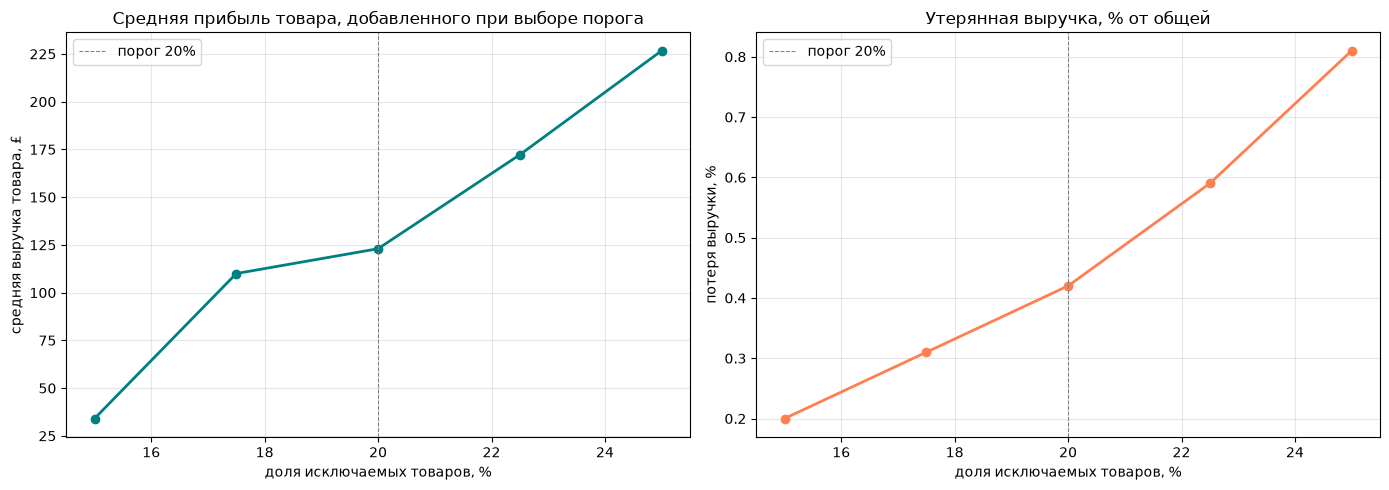

In [114]:
x = [float(t.rstrip('%')) for t in sensitivity['threshold']]
y_avg_rev_per_added = sensitivity['avg_rev_per_added'].astype(float).tolist()
y_perc_lost = sensitivity['revenue_perc'].astype(float).tolist()

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(x, y_avg_rev_per_added, marker='o', color='Teal', linewidth=2)
ax1.axvline(20, color='gray', linestyle='--', linewidth=0.75, label='порог 20%')
ax1.set_xlabel('доля исключаемых товаров, %')
ax1.set_ylabel('средняя выручка товара, £')
ax1.set_title('Средняя прибыль товара, добавленного при выборе порога')
ax1.grid(alpha=0.3)
ax1.legend()

ax2.plot(x, y_perc_lost, marker='o', color='Coral', linewidth=2)
ax2.axvline(20, color='gray', linestyle='--', linewidth=0.75, label='порог 20%')
ax2.set_xlabel('доля исключаемых товаров, %')
ax2.set_ylabel('потеря выручки, %')
ax2.set_title('Утерянная выручка, % от общей')
ax2.grid(alpha=0.3)
ax2.legend()

plt.tight_layout()
plt.show()

Мы можем наблюдать, что при переходе от 20% к 22,5% наблюдается **ускорение роста обоих графиков**. Порог в 20% кажется оптимальным решением: в таком случае под сокращение попадают 782 товара, принесшие за 12-месячный период всего 0,42% общей прибыли. 

#### Список кандидатов на сокращение

Составим список кандидатов на сокращение:

In [115]:
chosen_share = 0.2
target_n = int(products_num * chosen_share)
candidates = no_flag_cz.head(target_n).copy()
candidates.head(5)

,StockCode,units,orders,revenue,active_months,customers,rating
0,21009,1,1,1.25,1,0,9.34
1,84977,1,1,1.25,1,0,9.34
2,90092,1,1,1.66,1,0,12.60
3,21491,1,1,1.95,1,0,14.78
4,20860,1,1,2.10,1,0,18.03


Добавим в таблицу описание товаров. Так как у одного товара описание может различаться, выбрано первое встреченное в таблице `year_df` описание для каждого `StockCode`.

In [116]:
descriptions = (
    year_df
    .groupby('StockCode')['Description']
    .first()
    .reset_index()
)

candidates = candidates.merge(descriptions, on='StockCode', how='left')
candidates.head(5)

,StockCode,units,orders,revenue,active_months,customers,rating,Description
0,21009,1,1,1.25,1,0,9.34,ETCHED GLASS STAR TREE DECORATION
1,84977,1,1,1.25,1,0,9.34,WIRE FLOWER T-LIGHT HOLDER
2,90092,1,1,1.66,1,0,12.60,BLUE CRYSTAL BOOT PHONE CHARM
3,21491,1,1,1.95,1,0,14.78,SET OF THREE VINTAGE GIFT WRAPS
4,20860,1,1,2.10,1,0,18.03,GOLD COSMETICS BAG WITH BUTTERFLY


Проверим, для всех ли товаров найдено описание:

In [117]:
missing_num = candidates['Description'].isna().sum()
print(f'Без описания: {missing_num} товаров')

Без описания: 0 товаров


Добавим столбец с текстовой рекомендацией, подсвечивающей проблемные метрики товара. Для товаров с одной или несколькими сильными метриками добавлена рекомендация о ручной проверке.

In [118]:
def make_recommendation(row):
    """Собирает обоснование вывода товара из конкретных аргументов"""
    
    reasons = []
    warnings = []

    if row['orders'] <= 10:
        reasons.append(f"мало заказов ({int(row['orders'])})")
    if row['orders'] >= 100:
        warnings.append(f"{int(row['orders'])} заказа(ов)")

    if row['units'] <= 20:
        reasons.append(f"мало единиц продано ({int(row['units'])})")
    if row['units'] >= 200:
        warnings.append(f"{int(row['units'])} единиц(а) продано")

    if row['customers'] <= 5:
        reasons.append(f"мало идентифицированных покупателей ({int(row['customers'])})")
    if row['customers'] >= 50:
        warnings.append(f"{int(row['orders'])} идентифицированных покупателей")

    if row['active_months'] <= 3:
        reasons.append(f"редкие продажи ({int(row['active_months'])} мес.)")
    if row['active_months'] >= 7:
        warnings.append(f"продажи ({int(row['active_months'])} мес.)")
   
    if row['revenue'] < 100:
        reasons.append(f"низкая выручка ({row['revenue']:.0f} £)")
    if row['revenue'] > 500:
        warnings.append(f"выручка ({row['revenue']:.0f} £)")

    if not reasons:
        warnings.append('низкий общий рейтинг')
        return 'Рекомендуется ручная проверка:  '+ ', '.join(warnings)

    if reasons and warnings:
        return 'Рекомендуется ручная проверка:  '+ ', '.join(warnings) + '. Проблемы: ' + ', '.join(reasons)
    
    return 'Кандидат на удаление: ' + ', '.join(reasons)


candidates['Recommendation'] = candidates.apply(make_recommendation, axis=1)
pd.set_option('display.max_colwidth', 200)

Посмотрим, как рекомендации выглядят для SKU с самым низким суммарным рейтингом в списке:

In [119]:
candidates.head(5)

,StockCode,units,orders,revenue,active_months,customers,rating,Description,Recommendation
0,21009,1,1,1.25,1,0,9.34,ETCHED GLASS STAR TREE DECORATION,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (1 £)"
1,84977,1,1,1.25,1,0,9.34,WIRE FLOWER T-LIGHT HOLDER,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (1 £)"
2,90092,1,1,1.66,1,0,12.60,BLUE CRYSTAL BOOT PHONE CHARM,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
3,21491,1,1,1.95,1,0,14.78,SET OF THREE VINTAGE GIFT WRAPS,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
4,20860,1,1,2.10,1,0,18.03,GOLD COSMETICS BAG WITH BUTTERFLY,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"


И с самым высоким:

In [120]:
candidates.tail(5)

,StockCode,units,orders,revenue,active_months,customers,rating,Description,Recommendation
777,84231,108,20,72.63,5,13,1893.30,EASTER BUNNY WITH BASKET ON BACK,Кандидат на удаление: низкая выручка (73 £)
778,35001W,178,5,528.04,1,5,1896.34,HAND OPEN SHAPE DECO.WHITE,"Рекомендуется ручная проверка: выручка (528 £). Проблемы: мало заказов (5), мало идентифицированных покупателей (5), редкие продажи (1 мес.)"
779,16169K,225,8,94.50,4,8,1899.41,WRAP FOLK ART,"Рекомендуется ручная проверка: 225 единиц(а) продано. Проблемы: мало заказов (8), низкая выручка (94 £)"
780,90164B,37,14,133.50,7,7,1904.31,WHITE ROSEBUD PEARL BRACELET,"Рекомендуется ручная проверка: продажи (7 мес.), низкий общий рейтинг"
781,90129F,45,15,96.33,8,4,1907.60,RED GLASS TASSLE BAG CHARM,"Рекомендуется ручная проверка: продажи (8 мес.). Проблемы: мало идентифицированных покупателей (4), низкая выручка (96 £)"


Добавим столбцы с группами и средней ценой из датафрейма `abc_xyz`:

In [121]:
candidates = candidates.merge(
    abc_xyz[['StockCode', 'abc_group', 'xyz_group', 'abc_xyz', 'avg_price']],
    on='StockCode',
    how='left',
)

candidates.head(5)

,StockCode,units,orders,revenue,active_months,customers,rating,Description,Recommendation,abc_group,xyz_group,abc_xyz,avg_price
0,21009,1,1,1.25,1,0,9.34,ETCHED GLASS STAR TREE DECORATION,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (1 £)",C,Z,CZ,1.25
1,84977,1,1,1.25,1,0,9.34,WIRE FLOWER T-LIGHT HOLDER,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (1 £)",C,Z,CZ,1.25
2,90092,1,1,1.66,1,0,12.60,BLUE CRYSTAL BOOT PHONE CHARM,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)",C,Z,CZ,1.66
3,21491,1,1,1.95,1,0,14.78,SET OF THREE VINTAGE GIFT WRAPS,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)",C,Z,CZ,1.95
4,20860,1,1,2.10,1,0,18.03,GOLD COSMETICS BAG WITH BUTTERFLY,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)",C,Z,CZ,2.10


Рассчитаем процент выручки товара относительно общей:

In [122]:
candidates['revenue_perc'] = round(candidates['revenue'] / total_revenue * 100, 6)

Сформируем окончательный вариант таблицы с удобным порядком столбцов и сортировкой по рейтингу от меньшего к большему.

In [123]:
candidates = candidates[[
    'StockCode', 'Description',
    'abc_group', 'xyz_group', 'abc_xyz',
    'revenue', 'revenue_perc', 'units',
    'orders', 'customers', 'active_months', 'avg_price',
    'rating', 'Recommendation'
]]

candidates = candidates.sort_values('rating', ascending=True).reset_index(drop=True)

candidates.head(10)

,StockCode,Description,abc_group,xyz_group,abc_xyz,revenue,revenue_perc,units,orders,customers,active_months,avg_price,rating,Recommendation
0,21009,ETCHED GLASS STAR TREE DECORATION,C,Z,CZ,1.25,0.000012,1,1,0,1,1.25,9.34,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (1 £)"
1,84977,WIRE FLOWER T-LIGHT HOLDER,C,Z,CZ,1.25,0.000012,1,1,0,1,1.25,9.34,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (1 £)"
2,90092,BLUE CRYSTAL BOOT PHONE CHARM,C,Z,CZ,1.66,0.000016,1,1,0,1,1.66,12.60,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
3,21491,SET OF THREE VINTAGE GIFT WRAPS,C,Z,CZ,1.95,0.000019,1,1,0,1,1.95,14.78,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
4,20860,GOLD COSMETICS BAG WITH BUTTERFLY,C,Z,CZ,2.10,0.000021,1,1,0,1,2.10,18.03,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
5,84510e,SET OF 4 GREEN CAROUSEL COASTERS,C,Z,CZ,2.46,0.000024,1,1,0,1,2.46,21.29,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
6,82613a,"METAL SIGN,CUPCAKE SINGLE HOOK",C,Z,CZ,2.46,0.000024,1,1,0,1,2.46,21.29,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
7,85179a,GREEN BITTY LIGHT CHAIN,C,Z,CZ,2.46,0.000024,1,1,0,1,2.46,21.29,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
8,90112,PINK DOLLY HAIR CLIPS,C,Z,CZ,2.10,0.000021,2,1,0,1,1.05,21.43,"Кандидат на удаление: мало заказов (1), мало единиц продано (2), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"
9,90037A,TINY CRYSTAL BRACELET RED,C,Z,CZ,2.48,0.000025,1,1,0,1,2.48,23.47,"Кандидат на удаление: мало заказов (1), мало единиц продано (1), мало идентифицированных покупателей (0), редкие продажи (1 мес.), низкая выручка (2 £)"


Посчитаем метрики для товаров, которые предлагаются к выводу из ассортимента:

In [124]:
candidates_num = len(candidates)
candidates_perc = candidates_num / products_num * 100

candidates_rev = candidates['revenue'].sum()
rev_perc = candidates_rev / total_revenue * 100

print(f'Исходная выборка: {products_num:,} товаров')
print(f'Общая выручка за 12 месяцев: {total_revenue:,.0f} £')
print(f'Предлагается вывести: {candidates_num:,} товаров ({candidates_perc:.1f}% ассортимента)')
print(f'Историческая выручка кандидатов: {candidates_rev:,.0f} £')
print(f'Доля в общей выручке: {rev_perc:.2f}%')

Исходная выборка: 3,911 товаров
Общая выручка за 12 месяцев: 10,073,008 £
Предлагается вывести: 782 товаров (20.0% ассортимента)
Историческая выручка кандидатов: 42,795 £
Доля в общей выручке: 0.42%


Отобразим наглядно вклад кандидатов в ширину ассортимента и в выручку за исследуемый период:

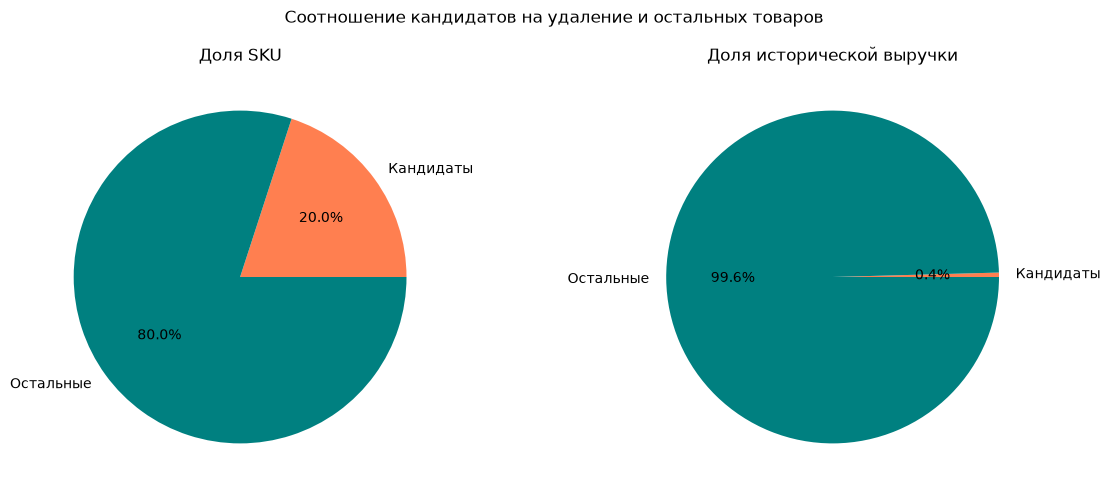

In [125]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

ax1.pie([candidates_num, products_num - candidates_num],
        labels=['Кандидаты', 'Остальные'],
        autopct='%1.1f%%', colors=['Coral', 'Teal'])
ax1.set_title('Доля SKU')

ax2.pie([candidates_rev, total_revenue - candidates_rev],
        labels=['Кандидаты', 'Остальные'],
        autopct='%1.1f%%', colors=['Coral', 'Teal'])
ax2.set_title('Доля исторической выручки')

plt.suptitle('Соотношение кандидатов на удаление и остальных товаров')
plt.tight_layout()
plt.show()

**Объём исходной выборки**: 3 911 уникальных SKU за последние 12 полных месяцев (декабрь 2010 – ноябрь 2011).

**Общая выручка за период** — 10 073 008 £.

**Кандидаты на вывод:** 782 SKU (20,0% ассортимента). Отобраны из группы CZ без меток — товаров с низкой выручкой и волатильным спросом. Внутри группы товарам присужден рейтинг на основе линейного ранжирования пяти метрик (выручка, заказы, проданные единицы, покупатели, активные месяцы). Порог 20% выбран как точка перегиба: при переходе к 22,5% средняя выручка добавляемых товаров резко растёт с 123 до 172 £, а потери выручки ускоряются.

**Историческая выручка кандидатов:** 42 795 £, что составляет 0,42% от общей выручки за период.

**Ключевое соотношение:** на 20% ассортимента приходится 0,42% выручки. Вклад каждого кандидата в выручку в среднем в 47 раз ниже, чем у среднего товара магазина.

**Из рассмотрения исключены:**
- 200 новых товаров (младше 6 месяцев) — недостаточно истории для решения;
- 97 молодых товаров (6–12 месяцев) — сезонность статистически не определяется;
- 34 сезонных товара — требуют особой стратегии закупки, а не вывода;
- товары с заметной выручкой и широкой аудиторией внутри CZ.

**Ограничение интерпретации:** доля выручки кандидатов — это исторический факт, а не прогноз. Она показывает, какой вклад эти товары внесли за прошедший год, но не предсказывает поведение покупателей после изменения ассортимента. Часть спроса может перераспределиться на аналогичные товары. Реальную потерю выручки можно будет измерить только после вывода и сравнения с контрольным периодом.

## 5. Итоги и выводы<a class="anchor" id="summary"></a>

1. **Выручка сильно сконцентрирована** на небольшой части ассортимента. За период декабрь 2010 – ноябрь 2011 общая выручка магазина составила 10 073 008 £ при 3 911 уникальных SKU.
   - 21,4% ассортимента (837 SKU) формируют 80,02% выручки — группа A;
   - 25,11% (982 SKU) дают 14,99% — группа B;
   - 53,49% (2 092 SKU) приносят 4,99% — группа C.
     Распределение почти точно соответствует классическому правилу Парето 80/20.

2. **Большая часть ассортимента пользуется нестабильным спросом**:
   - 7.98% (312 SKU) пользуются стабильным предсказуемым спросом - группа X;
   - 29.61% (1158 SKU) - спрос умеренно вариативен - группа Y;
   - 62.41% (2441 SKU) - сильно вариативный спрос - группа Z.

     Не для всех товаров из группы Z спрос можно назвать непредсказуемым. Среди причин вариативного, но не истинно непредсказуемого спроса можно назвать **новизну товара** и его **сезонный характер**. Таким товарам были присвоены метки.
   Они распределены по группам следующим образом:
   - 11.51% (450 SKU) - новые товары (полгода и менее с момента первой продажи). Все в группе Z;
   - 5.75% (225 SKU) - молодые товары (6-12 месяцев с момента первой продажи). Из них:
     * в группе X: 2 SKU;
     * в группе Y: 87 SKU;
     * в группе Z: 136 SKU;
   - 7.16% (280 SKU) - сезонные товары (подтверждено корреляцией Спирмена со сдвигом между двумя годами):
     * в группе Y: 112 SKU;
     * в группе Z: 168 SKU.

3. **Критично важные ABC/XYZ группы:**
   - AY (37.84% выручки, 362 SKU) — самая критичная группа. Она даёт больше трети выручки, при этом спрос колеблется. Это товары с наибольшим риском: и значимые, и нестабильные одновременно. Особое внимание — сезонным внутри AY (36 SKU);
   - AX (22.83% выручки, 209 SKU) — ядро ассортимента. 209 SKU приносят почти четверть выручки, спрос стабилен 11,99 месяцев из 12. Приоритет — не допускать дефицита;
   - AZ (19.35% выручки, 266 SKU) — самый сложный случай. Высокая выручка (19,35%) при хаотичном спросе и высокой средней цене (5,34 £). Здесь нужен ручной контроль запасов и, возможно, закупка под конкретные крупные заказы.

4. **Стратегия по управлению запасами:**
   - постоянное наличие + страховой запас: группы AX, BX, CX;
   - постоянное наличие с сезонной корректировкой: AY, BY;
   - осторожный запас, ручное управление: AZ, BZ;
   - закупка под спрос: CY, CZ.

     Подробнее [здесь](#strategy).

5. **Список кандидатов на сокращение** сформирован многоступенчато:

   - базовый пул: товары группы CZ без меток — не новые, не молодые, не сезонные;
   - для каждого товара рассчитан совокупный рейтинг по пяти метрикам: выручка, количество заказов, количество проданных единиц, количество покупателей, количество активных месяцев;
   - товары ранжированы по отсортированному рейтингу;
   - проведён анализ чувствительности при порогах 15%, 17,5%, 20%, 22,5% и 25% общего ассортимента. На его основании определён рекомендованный порог 20%;
   - составлен финальный список из 782 SKU — самых слабых по совокупному рейтингу. Для каждого сформирована текстовая рекомендация с конкретными основаниями.


6. **На сокращение предлагается 20,0% ассортимента — 782 SKU**

   После этого значения наблюдается скачок средней стоимости добавленного при выборе порога товара и одновременное ускорение роста гипотетических будущих потерь.


7. **Эти товары формировали 0,42% исторической выручки за исследуемый период** (42 795 £)

   Вклад среднего кандидата в выручку в 47 раз ниже, чем у среднего товара магазина (55 £ против 2 575 £). Это исторический факт, а не гарантированная потеря. Данные за прошлый период не предсказывают поведение покупателей после изменения ассортимента. Часть спроса может перераспределиться на аналогичные товары, часть — остаться неудовлетворённой. Реальная потеря выручки может быть измерена только после вывода товаров и сравнения с контрольным периодом.


8. **Риски решения:**

   - продажи могут быть не равны истинному спросу. У нас нет данных об остатках на складе и мы не можем говорить о том, всегда ли низкий спрос обусловлен невостребованностью товара или причиной является его недоступность для заказа из-за физического отсутствия;
   - роль товара в корзине. Товары CZ могут быть дополнениями к A-товарам. Удаление «довеска» может снизить продажи основного товара. Basket analysis не проводился;
   - риск удаления "нишевых", единственных в своём роде или редких товаров.
   
   **Рекомендуется ручная проверка для следующих товаров из списка:**
     - товары без провальных метрик, но с низким общим рейтингом;
     - кандидаты с одним сильным показателем (например, высокая средняя цена или заметное число покупателей при низкой выручке).

9. **Для более глубокого анализа не хватает данных о:**

    - себестоимости и марже по каждому SKU. Анализ опирается на выручку, а не на прибыль. Некоторые «слабые» SKU могут быть убыточными (тогда вывод оправдан ещё сильнее), некоторые — высокомаржинальными при низкой выручке (тогда вывод несёт скрытую потерю);
    - стоимости хранения. Сколько стоит одна позиция на складе в месяц. Это ключевой параметр для решения о выводе «мёртвого груза»;
    - остатках на складе по каждому SKU. Без этого нельзя понять, было ли количество товара достаточным для удовлетворения спроса;
    - истории статуса out-of-stock. Продажи не означают истинный спрос: если товара не было на складе, в транзакциях тоже будет ноль. Низкие продажи без данных о наличии нельзя трактовать как отсутствие интереса покупателей;
    - сроке годности и особых условиях хранения — для товаров соответствующей категории;
    - объёме упаковки товара и вместимости склада. Позволит оценить соотношение полезности товара и занимаемого им места.